### Simplest deterministic ED with power bounds and load balance 

$\min_{p_{i,t}} \sum_t^{T}\sum_i^{N_G} p^{G}_{i,t} c^{G}_g$

$\text{s.t.}~ \sum_i^{N_G} p^{G}_{t,i} = L_t ~ \forall t\in[T]$

$\text{s.t.}~ p^{Min}_i \leq p^{G}_{i,t} \leq p^{Max}_{i,t}$

#### BESS definition assumes a throughput/cycle (discharging) cost (charging per se costs nothing besides the system-generated energy cost), just splitting $P^G$ into $P^{ch}$ and $P^{dc}$ and considering $SOE$
$C^{op}_{BESS}[\$/\Delta t]=c_B[\$/kWh](P^{dc})[kWh/\Delta t]$ _Objective (sub)Function_ 

$0\leq P^{ch}_t\leq P^{ch}_{max}, ~ \forall t\in [T]$ charging bounds

$0\leq P^{dc}_t\leq P^{dc}_{max}, ~ \forall t\in [T]$ discharging bounds

$SOE_t=SOE_{t-1}+\Delta t(P^{ch}_t\eta^{ch} - P^{dc}_t/\eta_{dc}), ~ \forall t\in [T]\backslash\{1\}$, charge/discharge

$SOE_0=SOE_{init}$ initial condition

$SOE_T \geq SOE_0$, end condition

$SOE_1=SOE_{T}+\Delta t(P^{ch}_1\eta^{ch} - P^{dc}_1/\eta_{dc})$, charge/discharge circular (OPTIONAL, remove previous 2)

$0\leq SOE_t\leq C^E$ capacity constraint

#### And also add (circular) ramping limits on the gens (for the diesel one)

$ -DR^{Max}_i \leq p^{G}_{i,t}-p^{G}_{i,t-1} \leq UR^{Max}_{i} ~\forall t\in [T]\backslash\{1\}$

$ -DR^{Min}_i \leq p^{G}_{i,1}-p^{G}_{i,T} \leq UR^{Max}_{i}$

### Object Classes and Deterministic Dispatch Function

In [ ]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt  
from dataclasses import dataclass, field
import types
import logging

## For debugging purposes
logger = logging.getLogger(__name__)
FORMAT = "[%(filename)s:%(lineno)s - %(funcName)20s()] %(message)s"
logging.basicConfig(format=FORMAT)
logger.setLevel(logging.DEBUG)
# Use as follows
logger.debug("Hello world!")

## Generator Class
@dataclass
class Generator:
    type: str
    rate_copkwh: float
    power_perunit_kw: list
    power_kw: float = field(init=False)
    gen_curve: list = field(kw_only=True,default_factory=lambda: [])
    intermittent: bool = field(kw_only=True,default=False)
    dispatchable: bool = field(kw_only=True,default=True)
    IBR: int = field(kw_only=True,default=0)
    UR: float = field(kw_only=True,default=0)
    DR: float = field(kw_only=True,default=0)
    T: int = field(kw_only=True,default=24)
    def __post_init__(self):
        if len(self.power_perunit_kw)==0:
            raise Exception("useless generator")
        else:
            self.power_kw=sum(self.power_perunit_kw)
        match self.IBR:
            case 0: # Regular syn Gen, not an IBR. Does ED+R
                self.dispatchable=True
                self.intermittent=False
            case 1: # Fully P-controllable IBR, fixed bounds, like synGens. Does ED+R
                self.dispatchable=True
                self.intermittent=False
            case 2: # Non P-controllable IBR, e.g. MPPT SPV. Does ED, no R, random DeltaPout
                self.dispatchable=False
                self.intermittent=True
            case 3: # Short-term P-controllable IBR from intermittent source. Does ED+R.
                self.dispatchable=True
                self.intermittent=True
            case _:
                raise Exception("undefined IBR type")

        if not self.intermittent:
            self.gen_curve=np.ones(self.T)
        elif not len(self.gen_curve)==self.T:
            raise Exception(f"curve needs {self.T} periods")
        elif max(self.gen_curve)>1:
            raise Exception("curve is in p.u., <=1")
        if self.UR==0:
            self.UR=10*self.power_kw
        if self.DR==0:
            self.DR=10*self.power_kw

## BESS Class
@dataclass
class BESS:
    nmods: int = field(init=True)
    # default is Pylontech US5000, eff considering BMS/CC,inverter
    ch_eff: float = 0.86
    dc_eff: float = 0.83
    lifecycle: float = 8000 
    capcost_copkwh: float = field(default=1.4e6,repr=False) 
    modulecap_kwh: float = field(default=0.95*4.8,repr=False) #0.95 DoD
    modulepower_kw: float = field(default=4.8,repr=False)
    cap_kwh: float = field(init=False)
    power_kw: float = field(init=False)
    power_kw_ch: float = field(default=None)
    power_kw_dc: float = field(default=None)
    syscost_cop: float = field(init=False)
    throughput_kwh: float = field(init=False)
    dischargecostperkwh: float = field(init=False)

    def __post_init__(self):
        n=self.nmods
        self.cap_kwh=self.modulecap_kwh*n
        cap=self.cap_kwh
        self.power_kw=self.modulepower_kw*n
        self.power_kw_ch=self.power_kw if self.power_kw_ch is None else self.power_kw_ch # used for constr bounds
        self.power_kw_dc=self.power_kw if self.power_kw_dc is None else self.power_kw_dc # used for constr bounds
        self.syscost_cop=self.capcost_copkwh*cap
        self.throughput_kwh=self.lifecycle*cap
        self.dischargecostperkwh=self.syscost_cop/self.throughput_kwh

## Little Helper function to transform SOE to plot it
def SOEvectoplot(vec):
    return np.append(np.roll(vec,1),vec[-1])

## Microgrid Class
@dataclass
class MG:
    peak_demand_kW: float = field(init=True)
    demand_curve_pu: list = field(init=True)
    has_bess: bool = field(default=False)
    BESS: object = field(default=None)
    Gens: tuple = field(default=())
    def __post_init__(self):
        if not len(self.demand_curve_pu)==24:
            raise Exception("bruh, 24 hours")
        elif max(self.demand_curve_pu)>1:
            raise Exception("in p.u. means at most 1.0")

        if len(self.Gens)==0:
            raise Exception("No Generators defined")
        else:
            s=w=0
            for g in self.Gens:
                if g.IBR==2: # MPPT
                    if g.type in {'SPV','PV','Solar'}:
                        s+=1
                        if s>1: raise Exception("ONLY ONE TYPE 2 SOLAR GEN PER MG (represents aggregate)")
                    elif g.type in {'WP','WT','Wind'}:
                        w+=1
                        if w>1: raise Exception("ONLY ONE TYPE 2 WIND GEN PER MG (represents aggregate)")
                    else:
                        raise Exception("Undefined Type 2 Gen")
        if self.has_bess and self.BESS==None:
            print("please specify BESS")

## Deterministic Economic Dispatch
def detED(MG,T=24, gurobi_verbose=False,BESS_SOE_init=0,plot='',strictlycircularbess=False,minSOE=0,maxSOE=0,stackalpha=0.7,colors=plt.cm.Set1.colors):     
    global np,gp,GRB,plt
    #MG.Gens Params
    Ngen=len(MG.Gens)
    p_gmax_kw=np.array([g.power_kw for g in MG.Gens])
    p_gmin_kw=np.zeros(Ngen) #every gen can drop down to 0
    UR_kwhr=np.array([g.UR for g in MG.Gens])
    DR_kwhr=np.array([g.DR for g in MG.Gens])
    c_gen_copkwh=np.array([g.rate_copkwh for g in MG.Gens])
    gennames=[g.type for g in MG.Gens]
    p_gmax_pu_mtx=np.vstack([g.gen_curve for g in MG.Gens])
    
    #MG Params
    dem_peak_kw=MG.peak_demand_kW #Peak Demand
    dem_curve=MG.demand_curve_pu
    HAS_BESS=MG.has_bess
    
    m=gp.Model("ED1")
    pG=m.addMVar(shape=(Ngen,T),name="pG",vtype=GRB.CONTINUOUS)

    fobj=gp.LinExpr()
    for t in range(T):
        fobj+=c_gen_copkwh @ pG[:,t]

    m.addConstrs((pG[:,i]<=p_gmax_pu_mtx[:,i]*p_gmax_kw for i in range(T)),"pmax")
    m.addConstrs((pG[:,i]>=p_gmin_kw for i in range(T)),"pmin")
    m.addConstrs((pG[:,i+1]-pG[:,i]<=UR_kwhr for i in range(T-1)),"upramp")
    m.addConstr(pG[:,0]-pG[:,T-1]<=UR_kwhr,"upramp boundary")
    m.addConstrs((pG[:,i+1]-pG[:,i]>=-DR_kwhr for i in range(T-1)),"downramp")
    m.addConstr(pG[:,0]-pG[:,T-1]>=-DR_kwhr,"downramp boundary")
    
    if HAS_BESS:
        #MG BESS Params
        deltat_h=24/T
        p_dc_max_bess_kw=MG.BESS.power_kw_dc
        p_ch_max_bess_kw=MG.BESS.power_kw_ch
        CE_bess_kwh=MG.BESS.cap_kwh
        eta_ch=MG.BESS.ch_eff
        eta_dc=MG.BESS.dc_eff
        c_chdc_copkwh=MG.BESS.dischargecostperkwh
        SOE_init=BESS_SOE_init

        pCH=m.addMVar(shape=(T),lb=0,ub=p_ch_max_bess_kw)
        pDC=m.addMVar(shape=(T),lb=0,ub=p_dc_max_bess_kw)
        SOE=m.addMVar(shape=(T),lb=minSOE,ub=CE_bess_kwh-maxSOE)
        for t in range(T):
            fobj+=c_chdc_copkwh*(pDC[t])
        m.addConstrs((pG[:,i].sum()+pDC[i]-pCH[i]==dem_peak_kw*dem_curve[i] for i in range(T)),"loadbalance")
        m.addConstrs((SOE[t+1]==SOE[t]+deltat_h*(pCH[t+1]*eta_ch-pDC[t+1]/eta_dc) for t in range(T-1)),"SOE dynamics")
        if strictlycircularbess:
            m.addConstr(SOE[0]==SOE[T-1]+deltat_h*(pCH[0]*eta_ch-pDC[0]/eta_dc),"SOE circular")
        else:    
            m.addConstr(SOE[0]==SOE_init*CE_bess_kwh+deltat_h*(pCH[0]*eta_ch-pDC[0]/eta_dc),"SOE startcond")
            m.addConstr(SOE[T-1]>=SOE_init*CE_bess_kwh,"SOE endcond")
    else:
        m.addConstrs((pG[:,i].sum()==dem_peak_kw*dem_curve[i] for i in range(T)),"loadbalance")

    m.setObjective(fobj, GRB.MINIMIZE)
    m.params.LogToConsole=gurobi_verbose
    m.optimize()

    # plot with BESS constraints

    pG_res=pG.X
    genlabels=gennames

    if HAS_BESS:
        genlabels+=['BESS']
        pCH_res=pCH.X
        pDC_res=pDC.X
        SOE_res=SOE.X

        for t in range(T):
            if(pCH_res[t]>0 and pDC_res[t]>0):
                raise Exception("Battery is charging and discharging at same time for some reason (check if price is negative)")
            
        cP_mtx=np.transpose(np.tile(np.concatenate((c_gen_copkwh,[c_chdc_copkwh])),(T,1)))
        P_sys=np.concatenate((pG_res,[pDC_res-pCH_res]),axis=0)
        P_cost=np.concatenate((pG_res,[pDC_res]),axis=0)
    else:
        cP_mtx=np.transpose(np.tile(c_gen_copkwh,(T,1)))
        P_sys=pG_res
        P_cost=pG_res

    cP_res=P_cost*cP_mtx # costo de operacion de cada generador/bess por periodo, Ngen+hasbess x T
    cop_hr=np.sum(cP_res,axis=0) # costo de operacion por periodo, 1 x T
    dem_curve_kw=dem_curve*dem_peak_kw # demanda por periodo, 1 x T
    cop_kwh=cop_hr/(dem_curve_kw) # costo unitario de operacion por periodo, 1 x T 
    cop_kwh_avg=np.sum(cop_hr)/np.sum(dem_curve_kw) # costo unitario promedio diario
    # np.sum(cop_hr) === m.ObjVal

    EDresult=types.SimpleNamespace()
    EDresult.Cost=m.ObjVal
    EDresult.Pgen=pG_res
    if HAS_BESS:
        EDresult.PBESS=pDC_res-pCH_res
        EDresult.SOE=SOE_res

    import matplotlib.pyplot as plt
    import numpy as np

    periods = np.arange(0, 24+1/T, 24/T)
    fig, ax0 = plt.subplots(figsize=(12,8))
    
    # Graficar demanda y generación
    ax0.step(periods,dem_peak_kw*np.append(dem_curve,dem_curve[-1]),color="teal",linestyle='--',label='Demanda',where='post')
    colors = colors  # Paleta para Generadores
    ax0.set_xticks(periods)
    ax0.set_xlim((0,24))
    if(plot=='plot' or plot=='step'):
        for i,p in enumerate(P_sys):
            ax0.step(periods, np.append(p,p[0]), where='post', label=genlabels[i], alpha=0.8,color=colors[i]) #Clearer
    elif(plot=='bars'):
        n_sources, n_hours = P_sys.shape
        width=0.8/n_sources
        for i in range(n_sources):
            ax0.bar(periods[:-1] + (i+1)/(n_sources+1), P_sys[i], width, label=genlabels[i], color=colors[i % len(colors)])
        ax0.tick_params(axis='x',bottom=True,top=False,labelbottom=True,labeltop=False,direction='out')        
        axx=ax0.twiny()
        axx.spines['bottom'].set_position('zero')
        axx.set_xlim(ax0.get_xlim())
        axx.set_xticks(ax0.get_xticks())
        axx.tick_params(axis='x',bottom=True,top=False,labelbottom=False,labeltop=False,direction='out')
    else:
        ax0.stackplot(periods, np.concatenate((P_sys,np.array([P_sys[:,-1]]).T),axis=1), labels=genlabels, alpha=stackalpha,step='post',colors=colors) #Prettier
    ax0.set_xlabel('Tiempo (h)')
    ax0.set_ylabel('Potencia (kW)')
    h, l = ax0.get_legend_handles_labels()
    bbox1=(0.07,0.92)
    if HAS_BESS:
        # Segundo eje izquierda para el SOE
        ax1 = ax0.twinx()
        ax1.spines['left'].set_position(('axes', -0.12))  # Mover a la izquierda de ax0
        ax1.yaxis.set_label_position('left')
        ax1.yaxis.set_ticks_position('left')
        # SOE[2] es SOE(t=2:59), al final del período
        # se hace roll para mostrar el SOE acorde a la hora del punto
        ax1.plot(periods, SOEvectoplot(SOE_res), color='gold', linestyle='solid', label='SOE @ t:00')
        ax1.set_ylabel('SOE (MWh)', color='black')
        ax1.tick_params(axis='y', labelcolor='black')
        ax1.locator_params(nbins=12,axis='y')
        ax1.set_ylim((0,CE_bess_kwh*1.5))
        SOE_tick_labels=ax1.get_yticklabels()
        SOE_tick_labels = [f"{l.get_text()} - {float(l.get_text())/CE_bess_kwh:.0%}" for i,l in enumerate(SOE_tick_labels)]
        ax1.set_yticklabels(SOE_tick_labels)
        h2, l2 = ax1.get_legend_handles_labels()
        h+=h2
        l+=l2
        bbox1=(0.22,0.94)
    fig.legend(h, l, loc='upper left',bbox_to_anchor=bbox1, frameon=True)

    # Primer eje derecho (COP/kWh)
    ax2 = ax0.twinx()
    ax2.step(periods, np.append(cop_kwh,cop_kwh[-1]), where='post', color='black', linestyle='--', label='Costo unitario')
    ax2.set_ylabel('Costo unitario ($COP/kWh)')
    ax2.set_ylim((0,np.round(max(cop_kwh)*1.5/200,0)*200))
    ax2.tick_params(axis='y', labelcolor='black')

    # Segundo eje derecho (COP totales)
    ax3 = ax0.twinx()
    ax3.spines['right'].set_position(('axes', 1.1))  # Mueve el eje un poco más a la derecha
    ax3.step(periods, np.append(cop_hr,cop_hr[-1]), where='post', color='red', linestyle=':', label='Costo horario')
    ax3.set_ylabel('Costo horario ($COP/h)')
    ax3.set_ylim((0,np.round(max(cop_hr)*1.5/2.5e5,0)*2.5e5))
    ax3.tick_params(axis='y', labelcolor='black')
    ax3.yaxis.set_major_formatter('${x:,.0f}')

    h1, l1 = ax2.get_legend_handles_labels()
    h2, l2 = ax3.get_legend_handles_labels()
    fig.legend(h1 + h2, l1 + l2, loc='upper right',
            bbox_to_anchor=(0.8, 0.94),  # coordenadas dentro del gráfico
            frameon=True)

    ax0.text(0.02, 0.08,f"Promedio: ${cop_kwh_avg:,.0f} COP/kWh",transform=ax0.transAxes,fontsize=10,color='black',bbox=dict(facecolor='lightgray', alpha=0.8, edgecolor='none'))
    ax0.text(0.02, 0.04,f"Costo Diario: ${m.ObjVal:,.0f} COP",transform=ax0.transAxes,fontsize=10,color='black',bbox=dict(facecolor='lightgray', alpha=0.8, edgecolor='none'))
    
    # plt.title("Despacho acumulado con costo/demanda")
    plt.tight_layout()
    plt.show()
    
    return EDresult

[2383929465.py:15 -             <module>()] Hello world!


: 

In [ ]:
#### BESS EXAMPLES

lifecycle_optimism=1.25

M1_BESS=BESS(nmods=4)
print(M1_BESS)

# Fortress Power eVault Max 18.5 kWh 
M2_BESS=BESS(nmods=150,ch_eff=0.83,dc_eff=0.8,lifecycle=8000*lifecycle_optimism,capcost_copkwh=1.3e6,modulecap_kwh=0.8*18.5,modulepower_kw=9.2)
print(M2_BESS)

# ETHOS 5.12kWh Stackable Battery Module
M3_BESS=BESS(nmods=6,ch_eff=0.90,dc_eff=0.88,lifecycle=6000*lifecycle_optimism,capcost_copkwh=1.6e6,modulecap_kwh=0.8*5.12,modulepower_kw=2)
print(M3_BESS)

BESS1=BESS(nmods=732,ch_eff=0.83,dc_eff=0.8,lifecycle=8000*lifecycle_optimism,capcost_copkwh=1.2e6,modulecap_kwh=0.8*18.5,modulepower_kw=9.2) #Fortress Power eVault Max 18.5 kWh x nmods
print(BESS1)

BESS(nmods=4, ch_eff=0.86, dc_eff=0.83, lifecycle=8000, cap_kwh=18.24, power_kw=19.2, power_kw_ch=19.2, power_kw_dc=19.2, syscost_cop=29183999.999999996, throughput_kwh=145920.0, dischargecostperkwh=199.99999999999997)
BESS(nmods=150, ch_eff=0.83, dc_eff=0.8, lifecycle=10000.0, cap_kwh=2220.0, power_kw=1380.0, power_kw_ch=1380.0, power_kw_dc=1380.0, syscost_cop=2886000000.0, throughput_kwh=22200000.0, dischargecostperkwh=130.0)
BESS(nmods=6, ch_eff=0.9, dc_eff=0.88, lifecycle=7500.0, cap_kwh=24.576, power_kw=12, power_kw_ch=12, power_kw_dc=12, syscost_cop=39321600.0, throughput_kwh=184320.0, dischargecostperkwh=213.33333333333334)
BESS(nmods=732, ch_eff=0.83, dc_eff=0.8, lifecycle=10000.0, cap_kwh=10833.6, power_kw=6734.4, power_kw_ch=6734.4, power_kw_dc=6734.4, syscost_cop=13000320000.0, throughput_kwh=108336000.0, dischargecostperkwh=120.0)


Strictly Circular BESS restrictions:


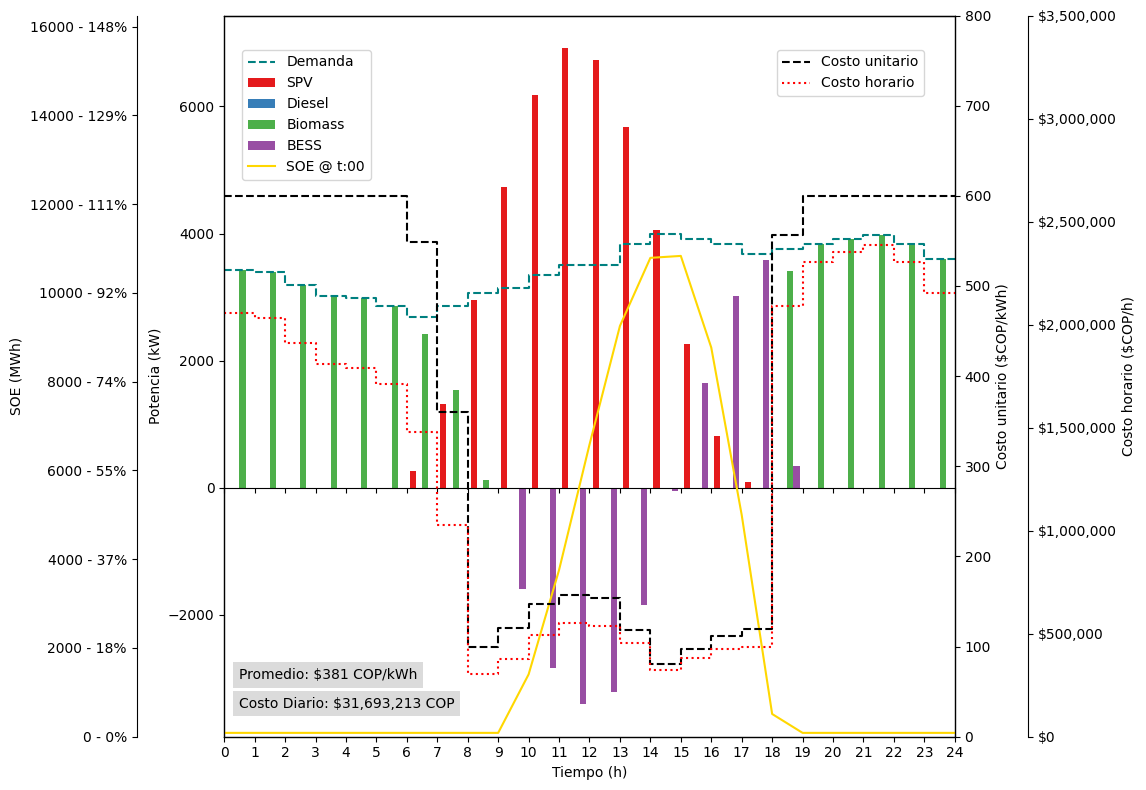

In [21]:
#### TESTING CLASSES AND DETERMINISTIC DISPATCH

a=Generator('Biomass',500,[1250]*2)
# print(a)
Diesel1=Generator('Diesel',800,[1000])
Biomass1=Generator('Biomass',600,[560]*8,UR=8*560,DR=8*560)
BESS_ex=BESS(nmods=6,ch_eff=0.83,dc_eff=0.8,capcost_copkwh=1.2e6,modulecap_kwh=0.8*18.5,modulepower_kw=9.2) #Fortress Power eVault Max 18.5 kWh 
MG_ex = MG(3000,np.array([0.261, 0.261, 0.261, 0.261, 0.261, 0.696, 0.652, 0.348, 0.348,0.522, 0.565, 0.609, 0.739, 0.696, 0.609, 0.565, 0.739, 0.87 ,0.957, 1.   , 1.   , 1.   , 0.87 , 0.435]),has_bess=True,BESS=BESS_ex,Gens=(Diesel1,Biomass1))

Biomass2=Generator('Biomass',300,[510]*2,UR=1200,DR=1200)
demc2=np.array([0.3,0.3,0.4,0.5,0.6,0.8,0.8,0.9,1,1,0.9,0.8,0.6,0.7,0.7,0.9,1,1,1,0.5,0.4,0.4,0.4,0.4])
MG2=MG(3000,demc2, Gens=(Diesel1,Biomass1))


### Testing detED

# regular curve, sunrise=6
# spvc1=np.array([0., 0., 0., 0., 0., 0., 0.01, 0.067, 0.25 ,0.5, 0.75, 0.933, 1., 0.933, 0.75, 0.5, 0.25, 0.067,0., 0., 0.,0., 0., 0.])
# sunrise~5:45am
spvc1=np.array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.038, 0.188, 0.421,
       0.676, 0.883, 0.988, 0.962, 0.812, 0.579, 0.324, 0.117, 0.012,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   ])
SPV1=Generator('SPV',80,[250]*28,IBR=3,gen_curve=spvc1)
Diesel1=Generator('Diesel',900,[1250,1000,910,510,510],UR=800,DR=800)
# print(f'BESS cost: ${BESS1.syscost_cop:,.0f} COP')
# print(BESS1)
demc1=np.array([0.857, 0.847, 0.796, 0.753, 0.745, 0.714, 0.673, 0.714, 0.765,0.786, 0.837, 0.878, 0.878, 0.959, 1., 0.98 , 0.959, 0.918,0.939, 0.959, 0.98 , 0.994, 0.959, 0.898])
MG1=MG(4000,demc1,True,Gens=(SPV1,Diesel1,Biomass1),BESS=BESS1)
print("Strictly Circular BESS restrictions:")
EDres=detED(MG1,plot='bars',strictlycircularbess=True)

# print("Interestingly, costs are the same either way! (I assume, as long as BESS doesn't get underused)")
# print("BESS starts at 0:")
# EDres_=detED(MG1,plot='bars',strictlycircularbess=False)

# from IPython.display import clear_output
# clear_output()

In [26]:
np.vstack([g.gen_curve*g.power_kw for g in MG1.Gens])
np.vstack([np.zeros(T)+g.power_kw*0.1 for g in MG1.Gens])

array([[700., 700., 700., 700., 700., 700., 700., 700., 700., 700., 700.,
        700., 700., 700., 700., 700., 700., 700., 700., 700., 700., 700.,
        700., 700.],
       [418., 418., 418., 418., 418., 418., 418., 418., 418., 418., 418.,
        418., 418., 418., 418., 418., 418., 418., 418., 418., 418., 418.,
        418., 418.],
       [448., 448., 448., 448., 448., 448., 448., 448., 448., 448., 448.,
        448., 448., 448., 448., 448., 448., 448., 448., 448., 448., 448.,
        448., 448.]])

### Metodología AGC/RSF
Sea: $\Delta\omega_{ss}(\Delta P_L=\Delta P_{L,max}^{+,-})=\Delta\omega_{max}^{-,+}$. Estos límites definen la regulación total requerida para la microrred:

$R_{MG} [\frac{Hz}{MW}]=-\frac{\Delta\omega_{ss}}{\Delta P_{L}}=\min(\frac{\Delta\omega_{max}^+}{|\Delta P_{L,max}^{-}|},\frac{|\Delta\omega_{max}^-|}{\Delta P_{L,max}^{+}})$

Ahora, se asignan factores de participación para regulación secundaria de frecuencia, de tal forma que $\Delta P^i_{G,ss}=\Delta P_{ref}^i=f^i_{part}\Delta P_L$, y $f_{part}^\top\mathbf{1}=1$. Esto se puede realizar de distintas maneras, dependiendo de las particularidades de la microrred:
- Asignar $f^i_{part}$ igual para todos los generadores.
- Asignar inversamente proporcional al costo de generación.
- Asignar proporcional a su potencia máxima.
- Asignar con base en sus límites de rampa, inercia (real o virtual).
- Asignar proporcionalmente al despacho asignado, ya sea por hora, o por total diario.
- Asignar un factor grande al BESS, si hay, y establecer los demás de acuerdo a una de las anteriores reglas.

Con esto se puede calcular los coeficientes de regulación (o coeficientes de droop) necesarios:

$R_i [\frac{Hz}{MW}]=-\frac{\Delta\omega_{ss}}{\Delta P^i_{G,ss}}=-\frac{\Delta\omega_{ss}}{f^i_{part}\Delta P_{L}}=\frac{R_{MG}}{f_{part}^i}$

Asumiendo que todos los generadores usan toda su holgura (reserve margins) cuando llegan al límite de frecuencia correspondiente $\Delta P^i_{G,ss}(\Delta\omega_{ss}=\Delta\omega_{max}^{-,+})=H_i^{+,-}$, entonces:

$f^i_{part}=\frac{H_i^{+,-}}{\Delta P_{L,max}^{+,-}}=\frac{R_{MG}}{R_i}\rightarrow H_i^{+,-}=f^i_{part}\Delta P_{L,max}^{+,-}$

Cabe resaltar que es igualmente viable definir una entre $f_{part}$, $R$ ó $H^{+,-}$ inicialmente y obtener con ello los otros dos parámetros. Otra forma común de configurar la RSF es estableciendo los coeficientes de droop normalizados $r[\frac{p.u.Hz}{p.u.MW}]:= R_i\frac{\bar{P_i}}{f_0}$, también llamado estatismo, en el mismo porcentaje para todos los generadores. Por ejemplo, la CREG establece que para el servicio de AGC en el SIN todos los generadores despachados centralmente tener un estatismo entre $4-6\%$, exceptuando plantas fotovoltaicas y eólicas, en las cuales debe ser configurable entre $2-6\%$. [Creg 90 2019]

### Despacho considerando holguras/márgenes de reserva:

Total Rsrv: +1.25MW, -1.60MW
Freq Limits: -0.5Hz, 0.5Hz, 
R_MG: 0.31Hz/MW, 2.083% puHz/puMW
Equal droops r: 20.39% puHz/puMW
Rescaling by 0.50 for intermittents
For ['SPV', 'Diesel', 'Biomass', 'BESS']
fpart: 11.51%, 13.75%, 14.74%, 60.00%
R: 31.67%, 15.83%, 15.83%, 5.85%% puHz/puMW
R: 2.71, 2.27, 2.12, 0.52 Hz/MW
H+: [143.91447368 171.875      184.21052632 750.        ]kW
H-: [184.21052632 220.         235.78947368 960.        ]kW
375.0kWh <= SOE <= CE - 480.0kWh


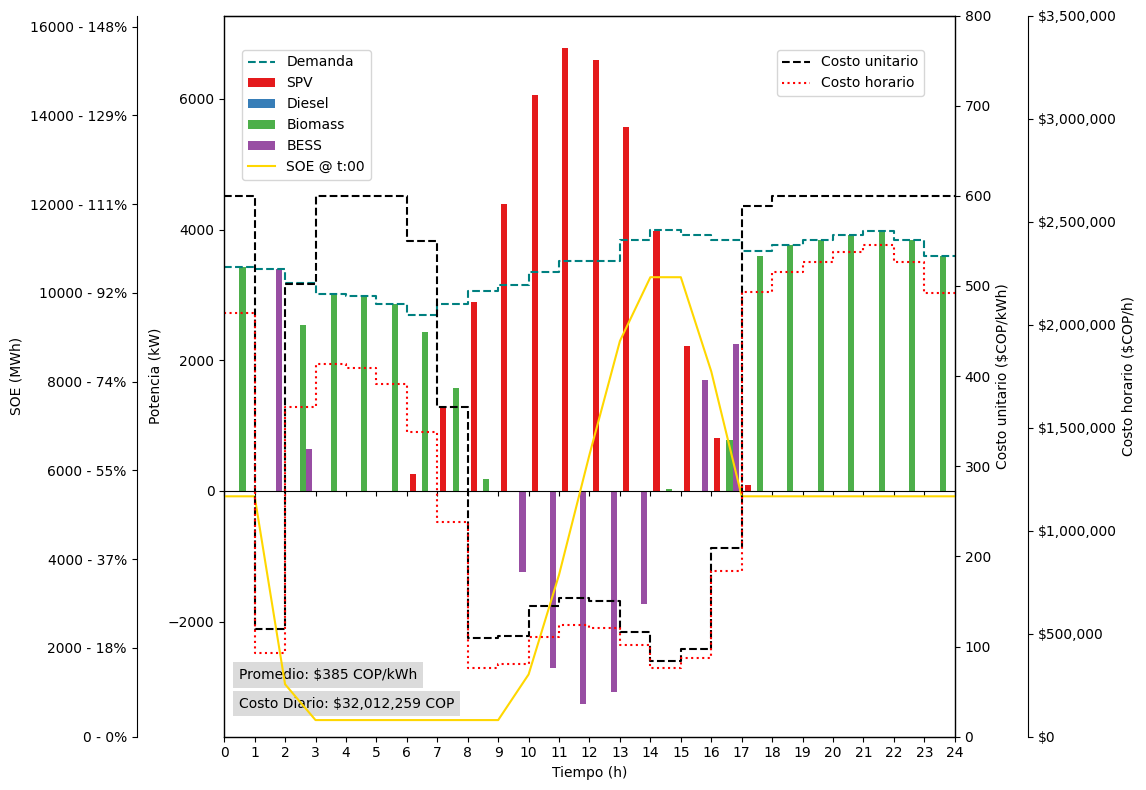

In [ ]:
## programar dispatch D-1 with reserve margins
from copy import deepcopy
import types

def detEDwithR(MG,T=24,customReserves=None,peakSupportedDisconn=0.4,f_hi=62,f_low=58.5,customReg=None,reservecost_wrt_gencost=0.2,fpart_bess=0.5,Type3GenFactor=0.5,agc_verbose=False,SOEmin_h=0.5,SOEmax_h=0.5,**kwargs):     
    # 0. Asumir criterios N-1 para establecer las necesidades totales de reserva
    Ngens,has_bess=len(MG.Gens),MG.has_bess
    ResupTotal,ResdownTotal=0,0
    if customReserves==None:
        # Capacidad más grande de unidad de generación (N-1)
        for g in MG.Gens:
            m=max(g.power_perunit_kw)
            ResupTotal=m if m>ResupTotal else ResupTotal
        # Carga más grande potencialmente desconectable (N-1), asumir 40% de peak demand  
        ResdownTotal=peakSupportedDisconn*MG.peak_demand_kW
    elif isinstance(customReserves,dict):
        # A menos que se estipule lo contrario
        ResupTotal=customReserves['up']
        ResdownTotal=customReserves['down']
    # 1. Definir estatismo total del sistema
    R_MGup=(f_hi-60)/ResdownTotal #Hz/kW
    R_MGlo=(60-f_low)/ResupTotal #Hz/kW
    # 2. Elegir la constante de regulación menor (más robusto)
    R_MG_max=min(R_MGup,R_MGlo) #Hz/kW'
    ###### Params globales MG
    if agc_verbose:
        print(f"Total Rsrv: +{ResupTotal/1000:.2f}MW, -{ResdownTotal/1000:.2f}MW")
        print(f"Freq Limits: {f_low-60}Hz, {f_hi-60}Hz, ")
        print(f"R_MG: {R_MG_max*1000:.2f}Hz/MW, {R_MG_max*MG.peak_demand_kW/60:.3%} puHz/puMW")

    # 3. Definir factores de participación y/o constantes de regulación
    fpart=[0]*(Ngens+has_bess) # % 
    R=[0]*(Ngens+has_bess) # Hz/kW
    # Usar constantes Reg custom, si hay
    if customReg is not None:
        if not len(customReg)==Ngens+has_bess:
            raise Exception("wrong length for customReg")
        else:
            R=customReg
            if np.min(R[np.nonzero(R)])<=R_MG_max:
                raise Exception("R_MG larger than customReg elements! Change MG reserve margins")
            fpart=[R_MG_max/Ri for Ri in R]
            # MODIFICAR SIGUIENTE PARA NO TOCAR LOS R CUSTOM? (permitir some Ri custom y setear demás en consecuencia)
            # ooooor just rely on proper Rcustom definition? (<--- for now)
    else:
        # BESS (si hay) hace la mayor parte del trabajo
        R_MG_remaining=R_MG_max #Hz/kW
        if has_bess:
            fpart[-1]=fpart_bess #%
            R[-1]=R_MG_max/fpart_bess #Hz/kW
            R_MG_remaining=R_MG_max/(1-fpart_bess) #Hz/kW
        
        CapTotDispatch=sum(g.power_kw for g in MG.Gens if g.dispatchable)
        # Si no hay despachables intermitentes (Tipo 3), definir cte regulación [pu] igual en todos (los que no son BESS)
        r=R_MG_remaining*CapTotDispatch/60 # igual para todos, en puHz/pukW
        if agc_verbose: print(f"Equal droops r: {r:.2%} puHz/puMW")
        # Si hay intermitentes no despachables (Tipo 2 o MPPT) asignarle R=10000% puHz/pukW
        rTipo3=100 # aka 10000%
        R[:Ngens]=[r*60/g.power_kw if g.dispatchable else rTipo3*60/g.power_kw for g in MG.Gens] # distinta en todos, en Hz/kW
        # print(f"i.e., R: {[x*1000 for x in R]} Hz/MW")
        fpart[:Ngens]=[R_MG_max/Ri for Ri in R[:Ngens]] #%
        if sum(g.intermittent for g in MG.Gens)>0:
        # Si hay despachables intermitentes (Tipo 3)
            if agc_verbose: print(f"Rescaling by {Type3GenFactor:.2f} for intermittents")
            fpart[:Ngens]=[Type3GenFactor*f if MG.Gens[i].intermittent else f for i,f in enumerate(fpart[:Ngens])] # su fpart_i será (Type3GenFactor, e.g. 0.5)x veces menor que los Tipo 1 presentes
            s=sum(f for f in fpart[:Ngens])# suma (de los non-bess)
            fpart[:Ngens]=[f*(1-fpart_bess*has_bess)/s for f in fpart[:Ngens]] # renormalizar para que los fpart sumen 1
            R[:Ngens]=[R_MG_max/f for f in fpart[:Ngens]]
    
    # 4. Definir Holguras
    # H_p=[0]*(Ngens+has_bess) # kW
    # H_n=[0]*(Ngens+has_bess) # kW
    H_n=np.array([ResdownTotal*f for f in fpart])
    H_p=np.array([ResupTotal*f for f in fpart])
    # Mostrar resultados de asignación de RSF
    R_pu=[Ri*MG.Gens[i].power_kw/60 for i,Ri in enumerate(R[:Ngens])]
    if has_bess: R_pu += [R[-1]*MG.BESS.power_kw/60]
    R_HzMw=[Ri*1000 for Ri in R]
    if agc_verbose:
        print(f"For {[g.type for g in MG.Gens]+has_bess*["BESS"]}")
        print(f"fpart: {", ".join([f"{f:.2%}" for f in fpart])}")
        print(f"R: {", ".join(f"{r:.2%}" for r in R_pu)}% puHz/puMW")
        print(f"R: {", ".join(f"{r:.2f}" for r in R_HzMw)} Hz/MW")
        print(f"H+: {H_p}kW")
        print(f"H-: {H_n}kW")
    
    # 5. Quitarle las holguras a los generadores para el despacho deterministico
    # Crear copia de microrred
    MG_R=deepcopy(MG)
    # print([g.power_kw for g in MG_R.Gens])
    for i,g in enumerate(MG_R.Gens):
        # Recortar las Capcds Max de los Gens por las holguras positivas
        ### ESTO ES INCORRECTO, YA ESTA CORREGIDO EN EDNRCLASSES
        g.power_kw -= H_p[i]
    # print([g.power_kw for g in MG_R.Gens])
    # print(MG_R.BESS)
    minSOE,maxSOE=0,0
    if has_bess:
        # Recortar Cap de descarga por H+ 
        MG_R.BESS.power_kw_dc -= H_p[-1]
        # Recortar Cap de carga por H-
        MG_R.BESS.power_kw_ch -= H_n[-1]
        # Minimo debe ser capaz de atender H+ por (SOEmin_h) horas
        minSOE = H_p[-1]*SOEmin_h
        # Y H- por (SOEmax_h) horas
        maxSOE = H_n[-1]*SOEmax_h #not really SOEmax, but the distance to CE
        if agc_verbose: print(f"{minSOE:.1f}kWh <= SOE <= CE - {maxSOE:.1f}kWh")
    # print(MG_R.BESS)
    # 6. Realizar ED y obtener costos (D-1) de Despacho y Reserva
    EDres = detED(MG=MG_R,T=T,minSOE=minSOE,maxSOE=maxSOE,**kwargs)
    EDnRresult=types.SimpleNamespace()
    EDnRresult.EDCost=EDres.Cost
    
    c_gen_copkwh=[g.rate_copkwh for g in MG.Gens]
    if MG.has_bess: c_gen_copkwh += [MG.BESS.dischargecostperkwh]
    EDnRresult.Rcost=reservecost_wrt_gencost*np.sum(H_p*c_gen_copkwh)

    # 7. Obtener resultados de ED+R
    EDnRresult.Pgen=EDres.Pgen
    if MG.has_bess:
        EDnRresult.PBESS=EDres.PBESS
        EDnRresult.SOE=EDres.SOE
        
    EDnRresult.ResupTotal=ResupTotal
    EDnRresult.ResdownTotal=ResdownTotal
    EDnRresult.fpart=np.array(fpart)
    EDnRresult.R_HzMw=np.array(R_HzMw)
    EDnRresult.R_pu=np.array(R_pu)
    EDnRresult.H_p=H_p
    EDnRresult.H_n=H_n
    return EDnRresult

customRes={"up":500,"down":500}
# detED(MG1,strictlycircularbess=True,minSOE=0,plot='bars')
_=detEDwithR(MG1,f_low=59.5,f_hi=60.5,fpart_bess=0.6,plot='bars',agc_verbose=True,gurobi_verbose=False,strictlycircularbess=False,BESS_SOE_init=0.5)
# print(EDres)
# from IPython.display import clear_output
# clear_output()



### Habiendo finalizado D-1, inicia D (Operation/Out-of-Sample Testing)

Durante la operación, la energía faltante en cada (sub)período $\Delta P_{mis}(t)=\Delta P_L(t)-\Delta P_{rnw}(t)$, que representa la demanda adicional no pronosticada y la energía no generada por parte de las plantas renovables no despachables, se cubre mediante la regla de decisión lineal $\Delta P_{ref}=f_{part}\Delta P_{mis}$, representativa de la regulación secundaria de frecuencia.

En caso de sobrepasar la holgura total de la microrred ($|\Delta P_L|>|\Delta P_{L,max}^{+,-}|$) se selecciona un generador de última instancia para cubrir totalmente el excedente por encima de la reserva total. 

Total Rsrv: +1.25MW, -1.60MW
Freq Limits: -1.5Hz, 2Hz, 
R_MG: 1.20Hz/MW, 8.000% puHz/puMW
Equal droops r: 43.30% puHz/puMW
Rescaling by 0.50 for intermittents
For ['SPV', 'Diesel', 'Biomass', 'BESS']
fpart: 0.07%, 19.27%, 20.66%, 60.00%
R: 20035.00%, 43.38%, 43.38%, 22.45%% puHz/puMW
R: 1717.29, 6.23, 5.81, 2.00 Hz/MW
H+: [  0.87347143 240.91788562 258.20864296 750.        ]kW
H-: [  1.11804342 308.37489359 330.50706299 960.        ]kW
375.0kWh <= SOE <= CE - 480.0kWh


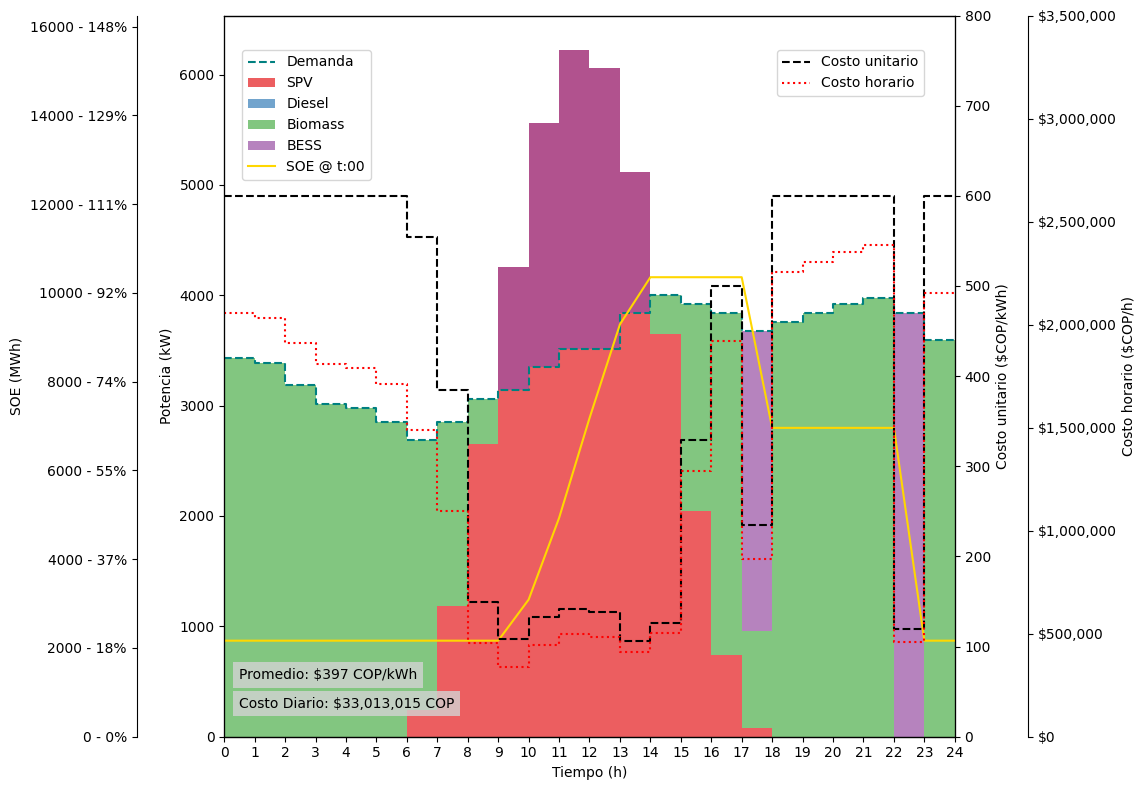

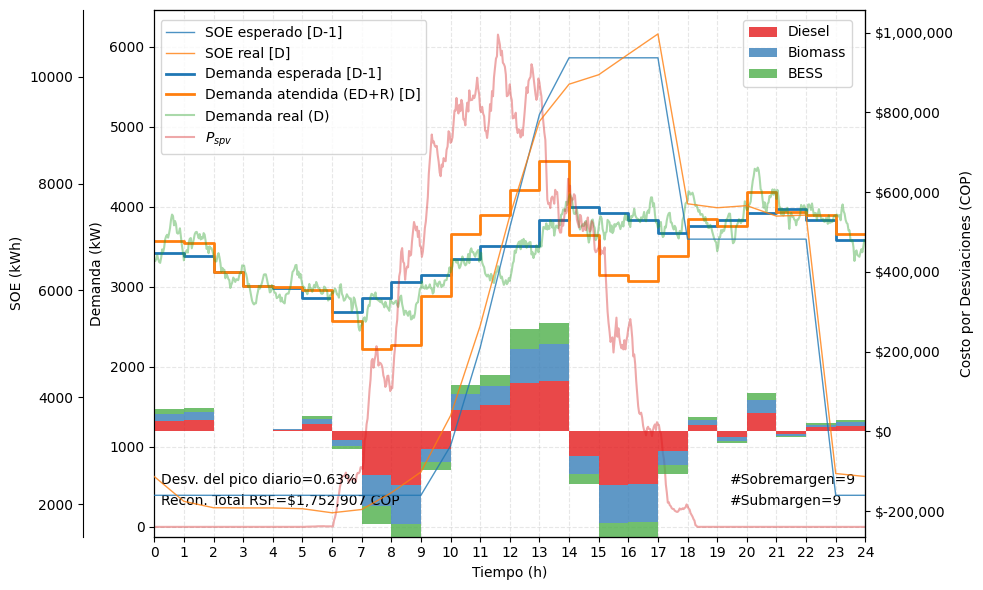

namespace(RecCost=1752907.018284669, Nover=9, Nunder=9)

In [18]:
from IPython.display import clear_output
from distfit import distfit
import scipy.stats as stats 
import numpy as np
import matplotlib.pyplot as plt
import yaml

with open('SolarPDF.yaml','r') as f:    
    solarinfo=yaml.safe_load(f)

with open('WindPDF.yaml','r') as f:    
    windinfo=yaml.safe_load(f)
    
def randomizeDemand(NominalPeak,NominalCurve_pu,rng,T=24,sigma_day=0.05,sigma_period=0.05,sigma_fast=0.15,window=12,subperiods=30):
    ###### Remember, +-2sigma~95%, 3sigma~99.7%
    # Daily variation
    realPeak=NominalPeak*(dayDev:=rng.normal(1,sigma_day))
    # Period variation
    realDemCurve_kw=realPeak*NominalCurve_pu*rng.normal(1, sigma_period, T)
    # Fast noise signal
    fastDemCurve=np.concatenate([periodDem*rng.normal(1,sigma_fast,subperiods) for periodDem in realDemCurve_kw])
    startfiller=rng.normal(1,sigma_fast,window-window//2-1)*realDemCurve_kw[-1]
    endfiller=rng.normal(1,sigma_fast,window//2)*realDemCurve_kw[0]
    fastDemCurve=np.concatenate([startfiller,fastDemCurve,endfiller])
    # linear decreasing filter
    # LPFimpResp=np.cumsum(np.ones(window))[::-1]/(window*(window+1)/2) 
    # regular moving average
    LPFimpResp=np.ones(window)/window
    fastDemCurve_LPF=np.convolve(fastDemCurve,LPFimpResp,mode='valid') #LPF aka promedio movil
    # fastDemCurve_LPF2=np.convolve(fastDemCurve_LPF,LPFimpResp,mode='valid') #LPF twice
    # print(fastDemCurve.shape)
    # print(fastDemCurve_LPF.shape)
    return fastDemCurve_LPF,dayDev

def SPVPower(GTI:'W/m2',PnomAtSTC_kw:'kW'):  # Po[kW]=Pstc[kW]*GTI[W/m2]/1000Wm2
    if hasattr(GTI,"__len__"):
        return [SPVPower(gti,PnomAtSTC_kw) for gti in GTI]
    else:
        return GTI*PnomAtSTC_kw/1000

def SolarRand(ExpectedCurve_kw,PnomAtSTC_kw,rng,window=9,subperiods=30,subsubperiods=3,roll_hours=0.2):
    """Delta Pout con respecto al promedio.
    Con base en Puerto Carreño (Solcast).
    SÓLO IMPLEMENTADO A T=24"""
    
    def solarSampleCutAvg(pdf_obj,rng,params,Nsamples,min_,max_):
        sample=np.array(pdf_obj.rvs(*params,size=Nsamples,random_state=rng))
        sample=sample[(min_<=sample)&(sample<=max_)]
        cutavg=sum(sample)/len(sample) if len(sample)>0 else min_
        # print(f"cutavg: {cutavg}")
        return cutavg

    T=24
    fastGTICurve=np.zeros(T*subperiods)
    # Fill fastGTICurve
    for t in range(T):
        pdf_t=solarinfo['solar'][t]
        max_=pdf_t['max']
        min_=pdf_t['min']
        params=[float(i) for i in pdf_t['params']]
        pdf_obj=getattr(stats,pdf_t['pdfname'])
        # print(t)
        sample_t=[solarSampleCutAvg(pdf_obj,rng,params,subsubperiods,min_,max_) for _ in range(subperiods)]
        # print(sample_t)
        fastGTICurve[t*subperiods:(t+1)*subperiods]=sample_t
    # print(f"fastGTI: {fastGTICurve}")
    #add fillers to fastCurve
    startfiller=np.zeros((window-window//2-1))
    endfiller=np.zeros(window//2)
    fastGTICurve=np.concatenate([startfiller,fastGTICurve,endfiller])
    # print(f"fastGTI w fillers: {fastGTICurve}")
    # linear decreasing filter
    # LPFimpResp=np.cumsum(np.ones(window))[::-1]/(window*(window+1)/2) 
    # regular moving average
    LPFimpResp=np.ones(window)/window
    fastGTICurve_LPF=np.convolve(fastGTICurve,LPFimpResp,mode='valid') #LPF aka promedio movil
    fastGTICurve_LPF=np.roll(fastGTICurve_LPF,int(roll_hours*subperiods))
    fastPoutCurve_LPF=np.array(SPVPower(fastGTICurve_LPF,PnomAtSTC_kw))
    fastDeltaPout=np.array([fastpo-ExpectedCurve_kw[i//subperiods] for i,fastpo in enumerate(fastPoutCurve_LPF)]) # Expected input nominal curve
    return fastPoutCurve_LPF,fastDeltaPout


def WTPower(vw_meas:'m/s',r:'m'=9,startVw:'m/s'=3,cutVw:'m/s'=25,pomax_unit:'kW'=100,H_meas:'m'=50,H_WT:'m'=50,airdensity:'kg/m3'=1.22)->'kW':
    if hasattr(vw_meas,"__len__"):
        wtpow_=[WTPower(r,vw,startVw,cutVw,pomax_unit,H_meas,H_WT) for vw in vw_meas]
        # logger.debug(f"wtpow_: {wtpow_}")
        return wtpow_
    else:
        vw_WT=vw_meas if H_meas==H_WT else vw_meas*(H_WT/H_meas)**0.17
        WindPower=1/2*airdensity*(np.pi*r**2)*vw_WT**3
        BetzCoeff=16/27
        NonIdeal=0.85
        if vw_meas<=cutVw and vw_meas>=startVw:
            ##### c_p as function of v_w
            decay=2.6 # smaller means max eff range is wider (~TSR-control is better)
            vw_maxeff=8 # peak efficiency wind speed
            nonideal_func=NonIdeal*2.7*(vw_meas/vw_maxeff)**decay*np.exp(-(vw_meas/vw_maxeff)**decay)+0.02*vw_meas # to up the end tail
            po=nonideal_func*BetzCoeff*WindPower/1e3
            ##### c_p static (perfect TSR-control)
            # xx=NonIdeal*BetzCoeff*WindPower/1e3
            return min(po,pomax_unit)
        else:
            return 0

def WindRand(ExpectedCurve_kw,N_100kw_units,rng,window=5,subperiods=30,subsubperiods=1):
    """DeltaPout con respecto al promedio.
    Con base en Sardinata (PDF de NASA Power
    renormalizado al promedio global de GlobalWindAtlas).
    SÓLO IMPLEMENTADO A T=24"""    
    
    def windSampleCutAvg(pdf_obj,rng,params,Nsamples,min_,max_):
        sample=np.array(pdf_obj.rvs(*params,size=Nsamples,random_state=rng))
        sample=sample[(min_<=sample)&(sample<=max_)]
        cutavg=sum(sample)/len(sample) if len(sample)>0 else min_
        # print(f"cutavg: {cutavg}")
        return cutavg

    T=24
    fastWSCurve=np.zeros(T*subperiods)
    # Fill fastWSCurve
    for t in range(T):
        pdf_t=windinfo['wind'][t]
        max_=pdf_t['max']
        min_=pdf_t['min']
        params=[float(i) for i in pdf_t['params']]
        pdf_obj=getattr(stats,pdf_t['pdfname'])
        sample_t=[windSampleCutAvg(pdf_obj,rng,params,subsubperiods,min_,max_) for _ in range(subperiods)]
        fastWSCurve[t*subperiods:(t+1)*subperiods]=sample_t
    #add fillers to fastCurve
    startfiller=fastWSCurve[-(window-window//2-1):]
    endfiller=fastWSCurve[:window//2]
    fastWSCurve=np.concatenate([startfiller,fastWSCurve,endfiller])
    # linear decreasing filter
    # LPFimpResp=np.cumsum(np.ones(window))[::-1]/(window*(window+1)/2) 
    # regular moving average
    LPFimpResp=np.ones(window)/window
    fastWSCurve_LPF=np.convolve(fastWSCurve,LPFimpResp,mode='valid') #LPF aka promedio movil
    # logger.debug(f"N_units: {N_100kw_units}")
    fastPoutCurve_LPF=np.array(WTPower(fastWSCurve_LPF))*N_100kw_units
    fastDeltaPout=np.array([fastpo-ExpectedCurve_kw[i//subperiods] for i,fastpo in enumerate(fastPoutCurve_LPF)]) # Expected input nominal curve
    # logger.debug(f"fastPoutCurve_LPF: {fastPoutCurve_LPF}")
    return fastPoutCurve_LPF,fastDeltaPout

def generate_day_sample(MG_,rng,subperiods=30):
    xi_i=types.SimpleNamespace()
    xi_i.subperiods=subperiods
    xi_i.fastDemandCurve,xi_i.dayDev=randomizeDemand(MG_.peak_demand_kW,MG_.demand_curve_pu,rng,subperiods=subperiods)
    for i,g in enumerate(MG_.Gens):
        if g.IBR==2: # MPPT
            NominalCurve=np.array(g.gen_curve)*g.power_kw
            match g.type:
                case 'SPV'|'PV'|'Solar':
                    xi_i.fastPSolar,xi_i.fastDeltaPSolar=SolarRand(NominalCurve,PnomAtSTC_kw=g.power_kw,rng=rng)
                case 'WP'|'WT'|'Wind':
                    xi_i.fastPWind,xi_i.fastDeltaPwind=WindRand(NominalCurve,N_100kw_units=len(g.power_perunit_kw),rng=rng)
                case _:
                    raise Exception("Undefined Type 2 Gen")
    return xi_i

def MGOperation(MG_,EDnRres,day_sample,LastInstance,/,subperiods=30,T=24,Type3HasReconCost=True,plot=False,plotFastEffDemand=True,plotDeltaSOE=True,colors=plt.cm.Set1.colors):
    if not day_sample.subperiods==subperiods:
        raise Exception("Sample subperiods do not match")
    # Get Randomized Demand from sample
    fastDemCurve,dayDev=day_sample.fastDemandCurve,day_sample.dayDev
    # Randomize DeltaGeneration (for Intermittents T2,T3)
    solarMPPTavailable=windMPPTavailable=False
    for i,g in enumerate(MG_.Gens):
        if g.IBR==2: # MPPT
            match g.type:
                case 'SPV'|'PV'|'Solar':
                    idx_solarMPPT=i # ONLY ONE TYPE 2 SOLAR GEN PER MG (represents aggregate)
                    solarMPPTavailable=True
                    fastPSolar,fastDeltaPSolar=day_sample.fastPSolar,day_sample.fastDeltaPSolar
                case 'WP'|'WT'|'Wind':
                    idx_windMPPT=i # ONLY ONE TYPE 2 WIND GEN PER MG (represents aggregate)
                    windMPPTavailable=True
                    fastPWind,fastDeltaPwind=day_sample.fastPWind,day_sample.fastDeltaPwind
                case _:
                    raise Exception("Undefined Type 2 Gen")
    fastDeltaGenCurve=np.zeros(T*subperiods)
    if(solarMPPTavailable):
        fastDeltaGenCurve+=fastDeltaPSolar
    if(windMPPTavailable):
        fastDeltaGenCurve+=fastDeltaPwind
    # Effective Demand = realDemand - DeltaGeneration
    fastEffDem=deepcopy(fastDemCurve)
    if(solarMPPTavailable|windMPPTavailable):
        fastEffDem-=fastDeltaGenCurve
    # Get Last Instance Gen's index
    if LastInstance=='BESS': iLI=-1
    else:
        for iLI,gLI in enumerate(MG_.Gens):
            if gLI.type==LastInstance:
                break
        else:
            raise Exception("Wrong Last Instance Name")
    ### Execute ED+Recourse Actions
    Nsources=len(MG_.Gens)+MG_.has_bess
    DeltaT=24/(T*subperiods) # en horas
    DeltaPG=np.zeros([Nsources,T])
    Nundermargin=Novermargin=0
    for tf,dem in enumerate(fastEffDem):
        tper=tf//subperiods
        periodForecastedDem=MG_.demand_curve_kW[tper]
        DeltaPL=dem-periodForecastedDem
        if DeltaPL==0: # No Recourse
            # DeltaPG[:,tper] += np.zeros(Nsources,1)
            continue
        elif DeltaPL>0: # Positive Recourse
            if overmargin:=(DeltaPL-EDnRres.ResupTotal)>=0:
                Novermargin+=1
                # Recourse = (Holguras Totales + Overmargin) del Last Instance * DeltaT
                DeltaPG[:,tper] += EDnRres.H_p*DeltaT 
                DeltaPG[iLI,tper] += overmargin*DeltaT
            else:
                # Recourse = fpart * DeltaPL * DeltaT
                DeltaPG[:,tper] += EDnRres.fpart*DeltaPL*DeltaT 
        elif DeltaPL<0: # Negative Recourse
            if undermargin:=(-DeltaPL-EDnRres.ResdownTotal)>=0:
                Nundermargin+=1
                # Recourse = (Holguras Totales + Overmargin) del Last Instance * DeltaT
                DeltaPG[:,tper] -= EDnRres.H_n*DeltaT 
                DeltaPG[iLI,tper] -= undermargin*DeltaT
            else:
                # Recourse = fpart * DeltaPL * DeltaT
                DeltaPG[:,tper] += EDnRres.fpart*DeltaPL*DeltaT
            # Recourse = (Holguras Totales + Overmargin) del Last Instance * DeltaT
    # Execute BESS Recourse actions
    ## SOE[2] = SOE(t=2:59), al final del período
    if MG_.has_bess:
        # calculate DeltaSOE
        DeltaSOE=np.zeros(T)
        for period,deltaPB in enumerate(DeltaPG[-1,:]):
            # can recourse actions make BESS ch and dc within same period? sure
            # but it's rare enough and (eta_ch-eta_dc are similar enough)
            # to ignore subperiod efficiency changes
            charging_at_period = (EDnRres.PBESS[period]+deltaPB<0)
            DeltaSOE[period] = -DeltaPG[-1,period]*24/T*(charging_at_period*MG_.BESS.ch_eff + (not charging_at_period)/MG_.BESS.dc_eff)
        # then acumulate to see cumsum(DeltaSOE) up to 23:59
        cumDeltaSOE=np.cumsum(DeltaSOE)
        # add to EDnRres.SOE to get SOE_real
        # # (it doesn't matter if circular or not, SOE(0:00) shouldn't change)
        SOE_real=np.sum([EDnRres.SOE,cumDeltaSOE],axis=0)
    
    # Calculate cost for t for all dispatchables, including BESS
    idxdispatchable=[i for i,g in enumerate(MG_.Gens) if g.dispatchable]
    gennames=[MG_.Gens[i].type for i in idxdispatchable]
    c_gens_copkwh=[MG_.Gens[i].rate_copkwh for i in idxdispatchable]
    if MG_.has_bess:
        idxdispatchable.append(-1)
        gennames.append('BESS')
        c_gens_copkwh.append(MG_.BESS.dischargecostperkwh)

    c_gens_tiled=np.tile(c_gens_copkwh,(T,1)).T
    op_cost=c_gens_tiled*DeltaPG[idxdispatchable,:]
    total_op_cost=np.sum(op_cost)
    # If Type 2s play in recourse cost, add it to opcost
    if Type3HasReconCost:
        if solarMPPTavailable:
            total_op_cost+=sum(MG_.Gens[idx_solarMPPT].rate_copkwh*fastDeltaPSolar)
        if windMPPTavailable:
            total_op_cost+=sum(MG_.Gens[idx_windMPPT].rate_copkwh*fastDeltaPwind)
    # Calculate period real (effective) demand
    realEffDemand=MG_.demand_curve_kW+np.sum(DeltaPG,axis=0)
    
# Plot
    if plot:
        periods=np.arange(0,24+1/T,24/T)
        fig,ax0=plt.subplots(figsize=(10,6))
        # Expected Demand (hourly)
        ax0.step(periods,np.append(MG_.demand_curve_kW,MG_.demand_curve_kW[-1]),where='post',lw=2,label='Demanda esperada [D-1]')
        # Effective Demand served with ED+R (hourly)
        ax0.step(periods,np.append(realEffDemand,realEffDemand[-1]),where='post',lw=2,label='Demanda atendida (ED+R) [D]')
        # Real Demand (fast)
        ax0.plot(np.arange(0,24*subperiods,24/T)/subperiods,fastDemCurve,label=f"Demanda real (D)",alpha=0.4)
        # Real Effective Demand (fast)
        if plotFastEffDemand: ax0.plot(np.arange(0,24*subperiods,24/T)/subperiods,fastEffDem,label=rf"Demanda efectiva (D)$",alpha=0.4)
        if solarMPPTavailable: ax0.plot(np.arange(0,24*subperiods,24/T)/subperiods,fastPSolar,label=rf"$P_{{spv}}$",alpha=0.4)
        if windMPPTavailable: ax0.plot(np.arange(0,24*subperiods,24/T)/subperiods,fastPWind,label=rf"$P_{{wp}}$",alpha=0.4)
        ax0.grid(True, linestyle='--', alpha=0.3)
        ax0.set_xticks(periods)
        ax0.set_xlim([0,24])
        ax0.set_ylabel('Demanda (kW)')
        ax0.set_xlabel('Tiempo (h)')
        ax0.set_ylim([ax0.get_ylim()[0]*0.4,ax0.get_ylim()[1]*1])
        # AGC Cost
        ax1=ax0.twinx()
        ax1.stackplot(periods,np.concatenate((op_cost,np.array([op_cost[:,-1]]).T),axis=1),labels=gennames,step='post',alpha=0.8,colors=colors)
        ax1.set_ylabel('Costo por Desviaciones (COP)')
        ax1.yaxis.set_major_formatter('${x:,.0f}')
        ylim=EDres.Cost/T
        ylim_vis=2
        pos=0.2
        ax1.set_ylim([-pos*2*ylim/ylim_vis,(1-pos)*2*ylim/ylim_vis])
        h0,l0=ax0.get_legend_handles_labels()
        h1,l1=ax1.get_legend_handles_labels()
        leg0,leg1=(0.08,0.97),(0.87,0.97)
        #Plot DeltaSOE
        if plotDeltaSOE and MG_.has_bess:
            ax2=ax0.twinx()
            ax2.spines['left'].set_position(('axes',-0.1))
            ax2.yaxis.set_label_position('left')
            ax2.yaxis.set_ticks_position('left')
            ax2.plot(periods,SOEvectoplot(EDnRres.SOE),lw=1,label='SOE esperado [D-1]',alpha=0.8)
            ax2.plot(periods,SOEvectoplot(SOE_real),lw=1,label='SOE real [D]',alpha=0.8)
            ax2.set_ylabel("SOE (kWh)")
            h,l=ax2.get_legend_handles_labels()
            h0,l0=h+h0,l+l0
            leg0=(0.165,0.97)
        fig.legend(h0,l0,loc='upper left', bbox_to_anchor=leg0, frameon=True)
        fig.legend(h1,l1,loc='upper right', bbox_to_anchor=leg1, frameon=True)
        ax1.text(0.01,0.1,f"Desv. del pico diario={dayDev-1:.2%}",transform=ax0.transAxes)
        ax1.text(0.01,0.06,f"Recon. Total RSF=${total_op_cost:,.0f} COP",transform=ax0.transAxes)
        ax1.text(0.81,0.1,f"#Sobremargen={Novermargin}",transform=ax0.transAxes)
        ax1.text(0.81,0.06,f"#Submargen={Nundermargin}",transform=ax0.transAxes)
        # Type 2 Gen
        plt.tight_layout()
        plt.show()

    operationResult=types.SimpleNamespace()
    operationResult.RecCost=total_op_cost
    operationResult.Nover=Novermargin
    operationResult.Nunder=Nundermargin
    
    yield operationResult

MG1_MPPT=deepcopy(MG1)
newgens=list(MG1_MPPT.Gens)
NOTCcurve=newgens[0].gen_curve*0.9 #Expected Curve pu is calculated as NOTC/STC (0.8) * Max Nominal Curve at STC
newgens[0]=Generator(newgens[0].type,newgens[0].rate_copkwh,newgens[0].power_perunit_kw,IBR=2,gen_curve=NOTCcurve)
MG1_MPPT.Gens=newgens
MG_=MG1_MPPT

EDnRres=detEDwithR(MG_,fpart_bess=0.6,agc_verbose=True,strictlycircularbess=True)
# clear_output()
rng=np.random.default_rng(0)
xi_i=generate_day_sample(MG1_MPPT,rng,subperiods=30)
LastInstance='BESS'
mgop=MGOperation(MG1_MPPT,EDnRres,xi_i,LastInstance,subperiods=30,T=24,Type3HasReconCost=True,plot=True,plotFastEffDemand=False,plotDeltaSOE=1)
next(mgop)

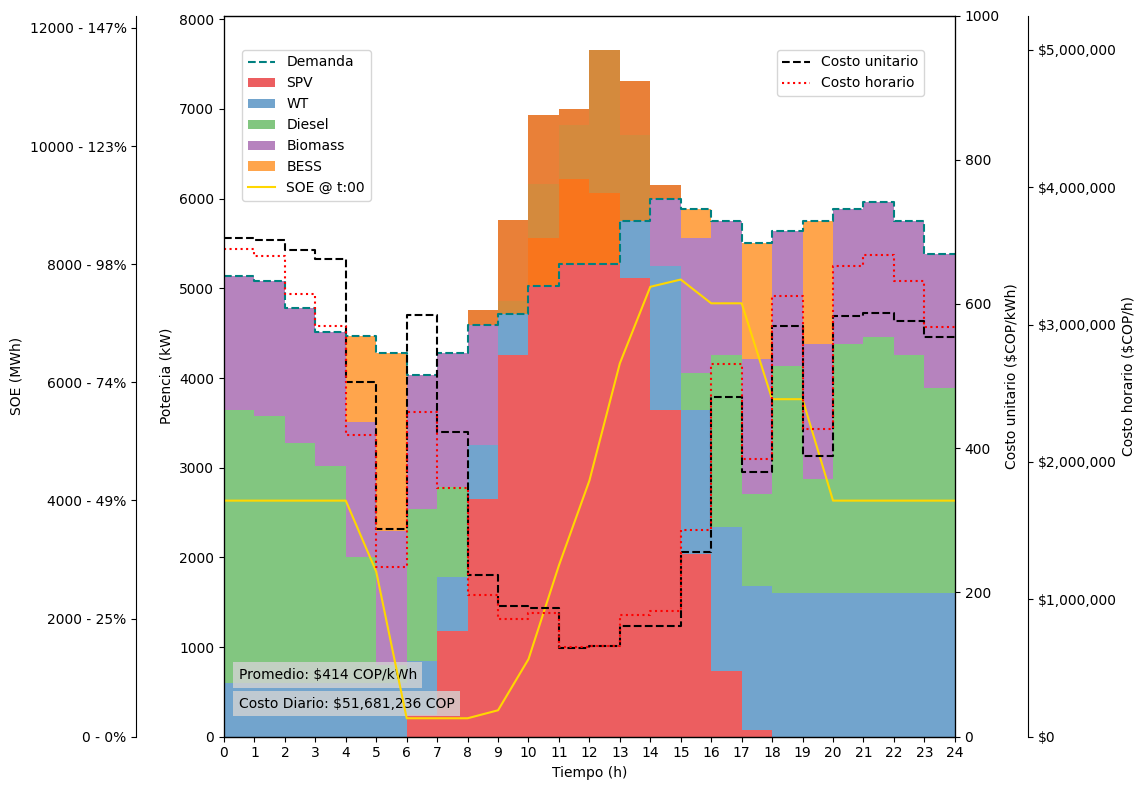

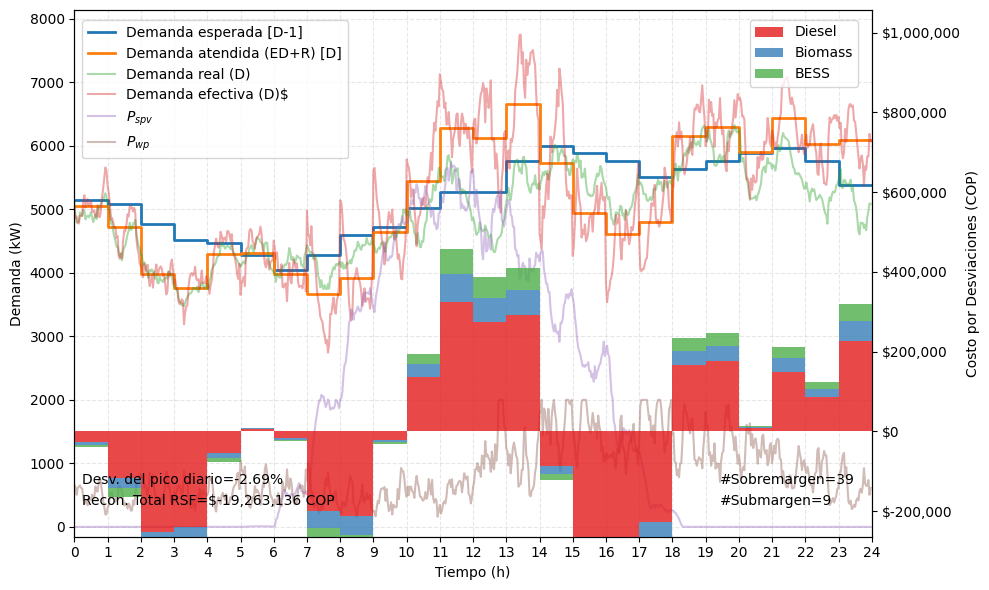

peakDem: 6066.309
avgDemCurve_pu: [0.856 0.853 0.799 0.755 0.731 0.7   0.676 0.718 0.771 0.79  0.84  0.869
 0.894 0.947 0.991 0.994 0.945 0.926 0.937 0.963 1.    0.989 0.945 0.905]
avgPsolarCurve_pu: [0.856 0.853 0.799 0.755 0.731 0.7   0.676 0.718 0.771 0.79  0.84  0.869
 0.894 0.947 0.991 0.994 0.945 0.926 0.937 0.963 1.    0.989 0.945 0.905]
avgPwCurve_pu: [0.856 0.853 0.799 0.755 0.731 0.7   0.676 0.718 0.771 0.79  0.84  0.869
 0.894 0.947 0.991 0.994 0.945 0.926 0.937 0.963 1.    0.989 0.945 0.905]


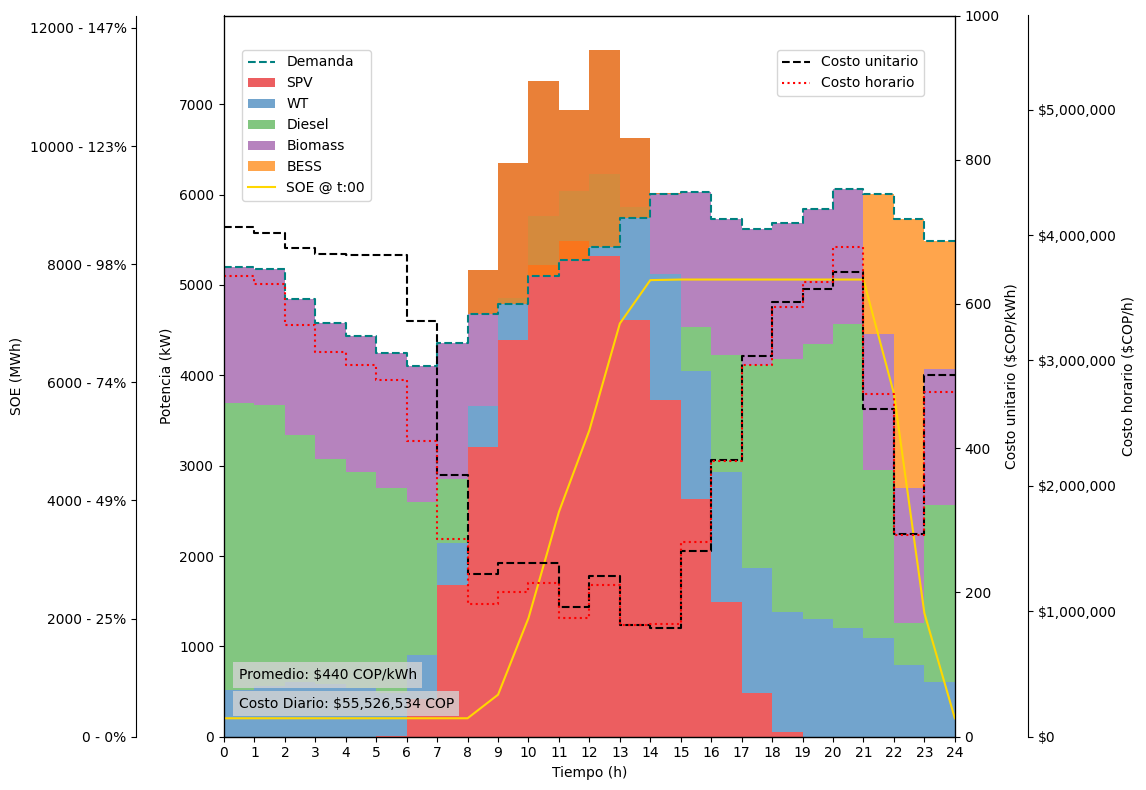

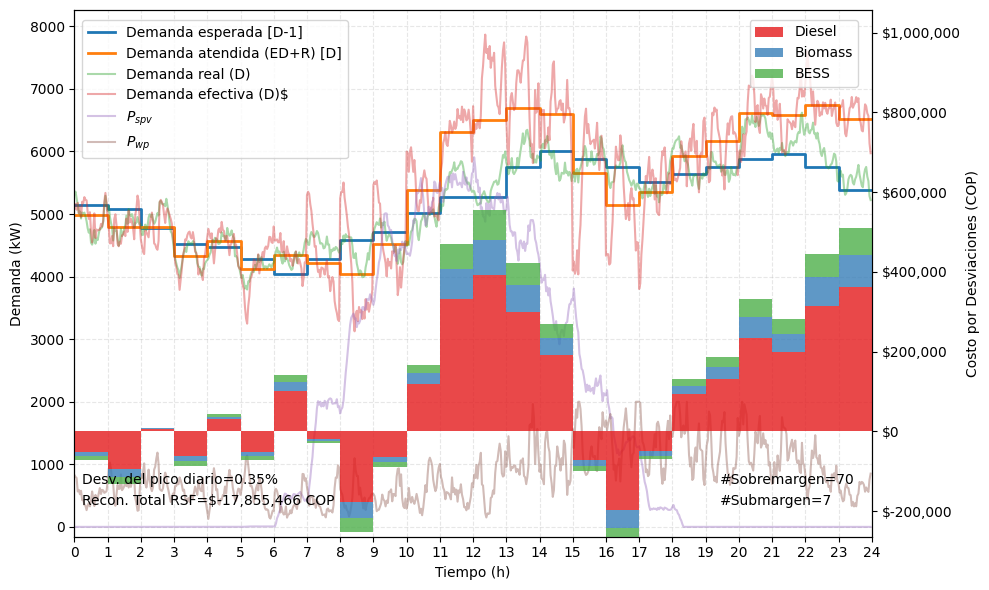

array([ 0.00065324, -0.0059456 , -0.00266778, -0.001825  ,  0.01433917,
        0.01361159, -0.00267363, -0.00394494, -0.00643606, -0.00373012,
       -0.00289484,  0.00892224, -0.01638379,  0.01198942,  0.00913731,
       -0.01445254,  0.01449577, -0.00828585,  0.00175769, -0.00442337,
       -0.02      ,  0.00470588,  0.01441255, -0.00696528])

In [9]:
#### DO detEDnR BUT WITH AVGS FROM DATA INSTEAD OF NOMINAL
# Nominal demand and Rnwable params
T=24

spvc1=np.array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.038, 0.188, 0.421,
       0.676, 0.883, 0.988, 0.962, 0.812, 0.579, 0.324, 0.117, 0.012,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   ])
# im kinda assuming 900W/m2 instead of nominal/STC(1kW/m2)
SPV_MPPT_1=Generator('SPV',80,[250]*28,IBR=2,gen_curve=spvc1*0.9) 
WT_MPPT_1=Generator('WT',110,[100]*20,IBR=2,gen_curve=[0.3]*12+[0.8]*12)
Diesel1=Generator('Diesel',900,[1250,1000,910,510,510],UR=1500,DR=1500)
Biomass1=Generator('Biomass',500,[560]*3,UR=3*200,DR=3*200)
demc1=np.array([0.857, 0.847, 0.796, 0.753, 0.745, 0.714, 0.673, 0.714, 0.765,0.786, 0.837, 0.878, 0.878, 0.959, 1., 0.98 , 0.959, 0.918,0.939, 0.959, 0.98 , 0.994, 0.959, 0.898])
BESS1=BESS(nmods=550,ch_eff=0.83,dc_eff=0.8,lifecycle=8000*lifecycle_optimism,capcost_copkwh=1.2e6,modulecap_kwh=0.8*18.5,modulepower_kw=9.2) #Fortress Power eVault Max 18.5 kWh x nmods
MG1_nominal=MG(6000,demc1,True,Gens=(SPV_MPPT_1,WT_MPPT_1,Diesel1,Biomass1),BESS=BESS1)

# Program ED + R
EDnR_Nominal=detEDwithR(MG1_nominal,strictlycircularbess=True,stackalpha=0.7)
# Operate once
rng=np.random.default_rng()
MGOperation(MG1_nominal,EDnR_Nominal,rng,'BESS',plot=True,plotDeltaSOE=False)

# Take a lot of randomizer samples for dem and renwbGen 
NParamSamples=20
subperiods=30
avgDemCurve=np.zeros(T)
avgPsolarCurve=np.zeros(T)
avgPwCurve=np.zeros(T)
for i in range(NParamSamples):
       # Make big sample of demand curves
       fastDemandSample,_=randomizeDemand(MG1_nominal.peak_demand_kW,MG1_nominal.demand_curve_pu,rng,subperiods=subperiods)
       periodDemandSample=np.array([sum(fastDemandSample[i*subperiods:(i+1)*subperiods])/subperiods for i in range(T)])
       avgDemCurve+=periodDemandSample
       # Make big sample of Rnwable curves
       # Solar
       fastSolarSample,_=SolarRand(SPV_MPPT_1.power_kw*spvc1,SPV_MPPT_1.power_kw,rng)
       periodSolarSample=[sum(fastSolarSample[i*subperiods:(i+1)*subperiods])/subperiods for i in range(T)]
       avgPsolarCurve+=periodSolarSample
       # Wind
       # logger.debug(f"i: {i}")
       fastWindSample,_=WindRand(WT_MPPT_1.power_kw*spvc1,len(WT_MPPT_1.power_perunit_kw),rng)
       # logger.debug(f"fastWindSample: {fastWindSample}")
       periodWindSample=[sum(fastWindSample[i*subperiods:(i+1)*subperiods])/subperiods for i in range(T)]
       avgPwCurve+=periodWindSample
avgDemCurve/=NParamSamples
avgPsolarCurve/=NParamSamples
avgPwCurve/=NParamSamples

# # get avg data
# periods=range(24)
# fig,ax=plt.subplots(figsize=(8,10))
# ax.step(periods,avgDemCurve,where='post',label='Dem')
# ax.step(periods,avgPsolarCurve,where='post',label='Sun')
# ax.step(periods,avgPwCurve,where='post',label='Wind')
# fig.legend(loc='upper left')

maxDem=max(avgDemCurve)
avgDemCurve_pu=avgDemCurve/maxDem
avgPsolarCurve_pu=avgPsolarCurve/(250*28)
avgPwCurve_pu=avgPwCurve/(100*20)
print(f"peakDem: {np.round(maxDem,3)}")
print(f"avgDemCurve_pu: {np.round(avgDemCurve_pu,3)}")
print(f"avgPsolarCurve_pu: {np.round(avgDemCurve_pu,3)}")
print(f"avgPwCurve_pu: {np.round(avgDemCurve_pu,3)}")

# run detEDnR with avgdata, compare to detEDnR with nominaldata
SPV_MPPT_2=Generator('SPV',80,[250]*28,IBR=2,gen_curve=avgPsolarCurve_pu) 
WT_MPPT_2=Generator('WT',110,[100]*20,IBR=2,gen_curve=avgPwCurve_pu)
MG1_avg=MG(maxDem,avgDemCurve_pu,True,Gens=(SPV_MPPT_2,WT_MPPT_2,Diesel1,Biomass1),BESS=BESS1)
# Program ED + R
EDnR_avg=detEDwithR(MG1_avg,strictlycircularbess=True,stackalpha=0.7)
# Operate once
rng=np.random.default_rng()
MGOperation(MG1_nominal,EDnR_avg,rng,'BESS',plot=True,plotDeltaSOE=False)


## TENGO QUE MENCIONAR JENSEN INEQUALITY PARA WIND ESPECIALLY (^3)
demc1-avgDemCurve_pu

### Kuhns's Reserve and Energy Dispatch - copperplate simplification

- Las variables de decisión son el despacho programado *ex-ante* (en D-1) $p_1$, los ajustes a la generación ("recourse") *ex-post* (en D) para una realización determinada de la incertidumbre ("realization/outcome") $p_2(\xi)$, y los márgenes u holguras de reserva asignados para RSF $r_+,r_-$ (en general asimétricos). Se usa una regla de decisión lineal (*linear decision rule*) común en optimización robusta, dónde $p_2(\xi)=Y\xi$. En particular, si se le asigna un factor de participación a cada generador despachable para cubrir el desbalance, se obtiene $Y=f_{part}\bar p_{rnw}^\top$, con $\mathbf 1^\top f_{part}=1$. Si bien es posible integrar información de la red para asignarle, por ejemplo, mayor contribución a un generador cercano al nodo de mayor desviación, la regla es congruente y compensa exactamente el desabalance del control primario por droop al elegir los coeficientes de droop proporcionales al factor de participación en la regulación secundaria. Además, es suficiente en una microrred, pues es aproximable como una red uninodal (*copperplate*).
- Los parámetros necesarios incluyen las capacidades máximas de los generadores despachables $\bar p$, sus costos de energía $c$, costos de asignación de capacidad a reserva $c_+,c_-$ (e.g. $0.2c$), máxima asignación de reserva positiva y negativa $\underline r,\bar r$ (e.g. $0.4\bar p$ o asimétricos), máximo flujo de potencia (DC-OPF) en cada línea $\bar F$, los PTDF para los generadores despachables y renovables y demandas ($Q^{g,rnw,d}$) y las capacidades máximas de los generadores renovables $\bar p_{rnw}$ (se asume que siempre son despachados, no implican costo, y no participan en  REFORMULAR PARA PERMITIR VERTIMIENTOS). Se asume que los costos liquidados por reconciliación tras la atención de desviaciones se pagan al mismo costo de energía del despacho $c$. 
- FALTA METER DINAMICA DE BATERIAS

$min_{p_1,f_part,r_+,r_-} ~ c^\top p_1+c^\top_+r_++c^\top_-r_-+ \mathbb E[c^\top f_{part}(\bar p_{rnw}^\top\xi)]$

$s.t.\quad 0 \leq r_+\leq\bar r, ~~ 0 \leq r_-\leq\underline r, ~~ \underline p\leq p_1-r_-, ~~ p_1+r_+\leq\bar p$

$\quad\quad\mathbb P[-r_-\leq Y\xi \leq r_+]\geq 1-\epsilon_{rsrv}$

$\quad\quad\mathbb P[-\bar f\leq Q^gp_1+Q^{rnw}\bar p_{rnw}\mu-Q^dd+(Q^gf_{part}\bar p_{rnw}^\top+Q^{rnw}diag(\bar p_{rnw}))\xi\leq\bar f]\geq 1-\epsilon_{rsrv}$

$\quad\quad~ \mathbf 1^\top diag(\bar p_{rnw})(\mu+\xi) + \mathbf 1^\top(p_1+p_2(\xi))=\mathbf 1^\top d$

$\rightarrow \mathbf 1^\top p_1+\mathbf 1^\top diag(\bar p_{rnw})\mu=\mathbf 1^\top d, ~~ \mathbf 1^\top f_{part}\bar p_{rnw}^\top + \mathbf 1^\top diag(\bar p_{rnw})=0$

## Sample Data for Wind Resources

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0.         0.0150075  0.03001501 0.04502251 0.06003002 0.07503752
 0.09004502 0.10505253 0.12006003 0.13506753 0.15007504 0.16508254
 0.18009005 0.19509755 0.21010505 0.22511256 0.24012006 0.25512756]


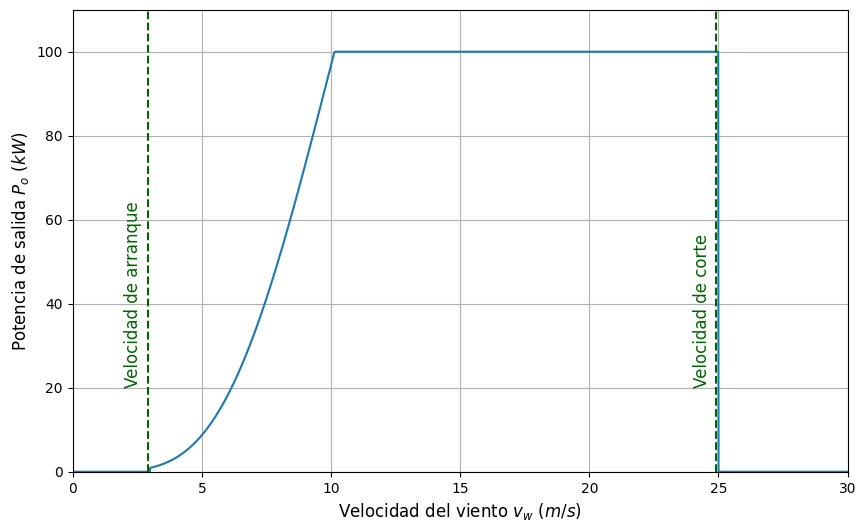

In [624]:
# Some WP numbers for Catatumbo, cerca a Ocaña o cerca a Sardinata p.ej.
MeanWindSpeed_ms=7 # globalwindatlas, at 100m
PlantFactor=0.20 # rule-of-thumb, 17-28% onshore, depends on wind data ofc, onshore
# https://www.alibaba.com/product-detail/10kw-20kw-50kw-80kw-100kw-220v_1600300205566.html
PeakperUnit_kw=50
CostperUnit_usd=13000
StartSpeed_ms=3
RatedSpeed_ms=12
CutOffSpeed_ms=25
BladeLength_m=6.4
Height_m=30 # you choose? i think 2*diam is about right

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def WTPower(r:'m',vw_meas:'m/s',startVw:'m/s',cutVw:'m/s',pomax:'kW',H_meas:'m',H_WT:'m',airdensity:'kg/m3'=1.22)->'kW':
    if not hasattr(vw_meas,"__len__"):
        vw_H_WT=vw_meas*(H_WT/H_meas)**0.17
        WindPower=1/2*airdensity*(np.pi*r**2)*vw_H_WT**3
        BetzCoeff=16/27
        NonIdeal=0.85
        if vw_meas<=cutVw and vw_meas>=startVw:
            ##### c_p as function of v_w
            decay=2 # bigger means max eff range is shorter (TSR-control is shittier)
            vw_maxeff=8 # peak efficiency wind speed
            nonideal_func=NonIdeal*2.7*(vw_meas/vw_maxeff)**decay*np.exp(-(vw_meas/vw_maxeff)**decay)
            nonideal_func+=0.03*vw_meas # to up the end tail
            xx=nonideal_func*BetzCoeff*WindPower/1e3
            ##### c_p static (perfect TSR-control)
            # xx=NonIdeal*BetzCoeff*WindPower/1e3
            return min(xx,pomax)
        else:
            return 0
    else:
        wpout=np.zeros(vw_meas.__len__())
        for i,x in enumerate(vw_meas):
            wpout[i]=WTPower(r,x,startVw,cutVw,pomax,H_meas,H_WT)
        return wpout
    
n=2000
wspeed=np.linspace(0,30,n)
wtpout=np.zeros(n)
BladeLength_m=9
PeakperUnit_kw=100
wtpout=WTPower(BladeLength_m,wspeed,StartSpeed_ms,CutOffSpeed_ms,PeakperUnit_kw,50,50)
print(wtpout[:18])
print(wspeed[:18])
# vector = pd.read_excel("IDEAM/IDEAM_VELOCIDADVIENTO.xlsx", sheet_name="CUCUTA", usecols="G")["Valor"].dropna().to_numpy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(wspeed,wtpout)
# ax.hist(wtpout)
ax.set_xlim([0,30])
ax.set_ylim([0,110])
ax.set_ylabel(r"Potencia de salida $P_o~(kW)$",fontsize=12)
ax.set_xlabel(r"Velocidad del viento $v_w~(m/s)$",fontsize=12)
ax.axvline(x=StartSpeed_ms-0.1, color='darkgreen', linestyle='--', linewidth=1.5)
ax.axvline(x=CutOffSpeed_ms-0.1, color='darkgreen', linestyle='--', linewidth=1.5)
ax.text(StartSpeed_ms-0.3,20,"Velocidad de arranque",color='darkgreen',fontsize=12,va='bottom',ha='right',rotation='vertical')
ax.text(CutOffSpeed_ms-0.3,20,"Velocidad de corte",color='darkgreen',fontsize=12,va='bottom',ha='right',rotation='vertical')
ax.grid(True)
# y_tick_positions = costos
# y_tick_labels = [f"$c_{{{i+1}}}$" for i in range(n)]
# ax.set_yticks(y_tick_positions)
# ax.set_yticklabels(y_tick_labels, fontsize=12)

56085
42310 -> 75.43906570384237%


(array([2.0882e+04, 0.0000e+00, 1.9800e+03, 1.8840e+03, 1.9730e+03,
        1.8360e+03, 1.1500e+03, 1.5710e+03, 5.2600e+02, 1.0090e+03,
        4.6200e+02, 1.3760e+03, 5.0000e+00, 7.4100e+02, 3.4600e+02,
        7.8500e+02, 2.5300e+02, 6.0000e+02, 7.0000e+00, 2.1800e+02,
        5.3400e+02, 1.4300e+02, 5.4000e+01, 4.5100e+02, 1.8000e+02,
        1.0000e+00, 0.0000e+00, 4.0400e+02, 1.2300e+02, 2.3900e+02,
        1.4900e+02, 0.0000e+00, 1.2400e+02, 3.1100e+02, 1.0000e+00,
        0.0000e+00, 8.7000e+01, 3.0700e+02, 0.0000e+00, 8.2000e+01,
        0.0000e+00, 3.0000e+00, 2.8600e+02, 0.0000e+00, 7.1000e+01,
        0.0000e+00, 1.0000e+00, 2.3400e+02, 0.0000e+00, 9.2100e+02]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50.]),
 <BarContainer object of 50 a

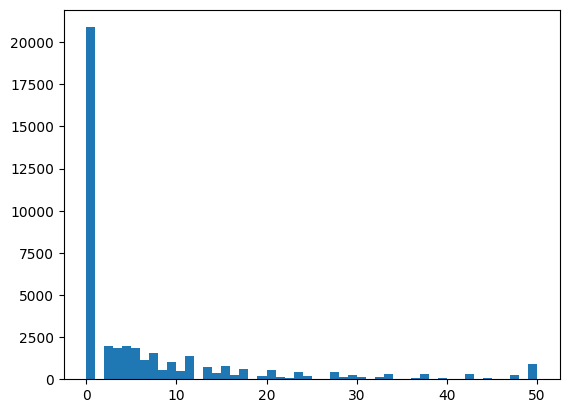

In [ ]:
print(vector.size)
vectorf=vector[np.where(vector>=1)]
print(f"{vectorf.size} -> {vectorf.size/vector.size *100}%")
# plt.xlim([0,15])
# plt.hist(vectorf,bins=50)

wtpout=WTPower(BladeLength_m,vectorf,StartSpeed_ms,CutOffSpeed_ms,PeakperUnit_kw,20,100)

plt.hist(wtpout,bins=50)
# plt.xlim([0,15])

time
2014-06-21 00:00:00    6.923578
2014-06-21 01:00:00    7.993087
2014-06-21 02:00:00    8.743541
2014-06-21 03:00:00    9.062595
2014-06-21 04:00:00    9.325191
Name: WS50M_Sardinata, dtype: float32

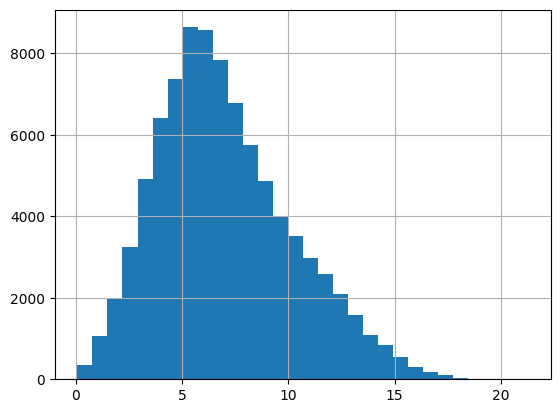

In [9]:
# Sacando datos de velocidad del viento en el Catatumbo

import pandas as pd
import xarray as xr

from datetime import datetime

lat,lon=8,-73
latC,lonC=7.5,-72.5 # Cerca a Cúcuta
latS,lonS=8.0,-72.5 # Cerca a Sardinata
latA,lonA=8.0,-73.125 # Cerca a Ábrego

startdate,enddate=datetime(2014, 6, 21),datetime(2024, 6, 21)

filepath = 'https://nasa-power.s3.us-west-2.amazonaws.com/merra2/temporal/power_merra2_hourly_temporal_utc.zarr/'
ds_wind = xr.open_zarr(store=filepath, consolidated=True)
wspeed50m=ds_wind.WS50M.sel(lat=slice(lat-1.5,lat+1.5),lon=slice(lon-1.5,lon+1.5),time=pd.date_range(startdate, enddate, freq='h')).load().to_dataframe() # Wind Speed at 50m 0.5deg x 0.625deg 
airdensity=ds_wind.RHOA.sel(lat=latS,lon=lonS,time=pd.date_range(startdate, enddate, freq='h'),method='nearest').load().to_dataframe() # Surface Air Density

wspeed50m=wspeed50m.reset_index()
wspeed50m['tempcol']=wspeed50m.apply(lambda row: f"WS50M_{row['lat']}_{row['lon']}", axis=1)
wspeed50m=wspeed50m.pivot(index='time', columns='tempcol', values='WS50M').sort_index(axis=1)
wspeed50m=wspeed50m[["WS50M_8.0_-73.125","WS50M_8.0_-72.5","WS50M_7.5_-72.5"]]
wspeed50m.columns=["WS50M_Abrego","WS50M_Sardinata","WS50M_Cucuta"]

# with pd.option_context("display.max_rows",100):
#     print(wspeed50m)

ws_sard_m=wspeed50m["WS50M_Sardinata"].mean()
# Renormalizando utilizando la velocidad del viento promedio obtenida de Global Wind Atlas (cheating? lol)
ws_sard=wspeed50m["WS50M_Sardinata"]*7/ws_sard_m
ws_sard.hist(bins=30)
ws_sard.head()

# Wind Power Distribution
# wp_sard_og=wspeed50m["WS50M_Sardinata"].apply(lambda x: WTPower(BladeLength_m,x,StartSpeed_ms,CutOffSpeed_ms,PeakperUnit_kw,50,50))
# print(wp_sard_og.mean())
# wp_sard_og.hist(bins=30,alpha=0.5)
# wp_sard=ws_sard.apply(lambda x: WTPower(BladeLength_m,x,StartSpeed_ms,CutOffSpeed_ms,PeakperUnit_kw,50,50))
# print(wp_sard.mean())
# wp_sard.hist(bins=30,alpha=0.5)



# filepath = 'https://nasa-power.s3.us-west-2.amazonaws.com/syn1deg/temporal/power_syn1deg_hourly_temporal_utc.zarr'
# ds_sun = xr.open_zarr(store=filepath, consolidated=True)
# GHI=ds_sun.ALLSKY_SFC_LW_DWN.sel(lat=lat,lon=lon,time=pd.date_range(startdate, enddate, freq='h'),method='nearest').load().to_dataframe() # Shortwave Downward Irradiance aka GHI, resolution 1deg x 1deg
# zenith=ds_sun.SZA.sel(lat=lat,lon=lon,time=pd.date_range(startdate, enddate, freq='h'),method='nearest').load().to_dataframe() # Solar Zenith Angle 

# # different ways to slice the data
# ds_single_point = ds.ALLSKY_SFC_LW_DWN.sel(lat=39, lon=-77, method='nearest').load()
# # ds_single_time = ds.ALLSKY_SFC_LW_DWN.sel(time=datetime(2022, 12, 31)).load()
# ds_time_series = ds.ALLSKY_SFC_LW_DWN.sel(time=pd.date_range(datetime(2020, 12, 27), datetime(2020, 12, 31), freq='h')).load()
# ds_region = ds.ALLSKY_SFC_LW_DWN.sel(lat=slice(35, 45), lon=slice(-85, -75)).load()

Index(['WS_00', 'WS_01', 'WS_02', 'WS_03', 'WS_04', 'WS_05', 'WS_06', 'WS_07',
       'WS_08', 'WS_09', 'WS_10', 'WS_11', 'WS_12', 'WS_13', 'WS_14', 'WS_15',
       'WS_16', 'WS_17', 'WS_18', 'WS_19', 'WS_20', 'WS_21', 'WS_22', 'WS_23'],
      dtype='object')


,fecha,WS_00,WS_01,WS_02,WS_03,WS_04,WS_05,WS_06,WS_07,WS_08,...,WS_14,WS_15,WS_16,WS_17,WS_18,WS_19,WS_20,WS_21,WS_22,WS_23
0,2014-06-21,6.923578,7.993087,8.743541,9.062595,9.325191,9.100044,8.987470,8.518394,8.312027,...,10.469826,10.132105,10.451045,10.976351,11.539335,11.745701,11.351635,10.582400,8.668530,7.205070
1,2014-06-22,6.961141,6.829785,6.754660,5.872850,6.660868,7.280081,6.173009,5.685266,6.998589,...,15.685901,15.779693,15.873600,15.873600,15.366961,14.578943,13.453091,11.295405,8.143224,6.717212
2,2014-06-23,7.880513,9.118825,9.813050,10.413482,10.300908,9.738039,9.531672,9.456547,9.025033,...,11.820712,12.571280,12.496156,12.327352,12.364915,12.252340,12.027079,11.126488,8.874896,8.912459
3,2014-06-24,9.663028,9.963186,9.587902,9.719257,9.118825,9.325191,9.775601,10.207115,10.920121,...,13.903386,15.010457,15.104250,14.672736,14.353796,13.959730,13.021576,11.558002,9.400317,8.555956
4,2014-06-25,9.006251,9.512891,9.419099,9.043815,7.955524,7.317644,6.548294,6.285583,5.610140,...,4.540631,5.722714,6.979808,7.692813,8.274465,8.818666,9.419099,9.062595,9.381536,10.150771


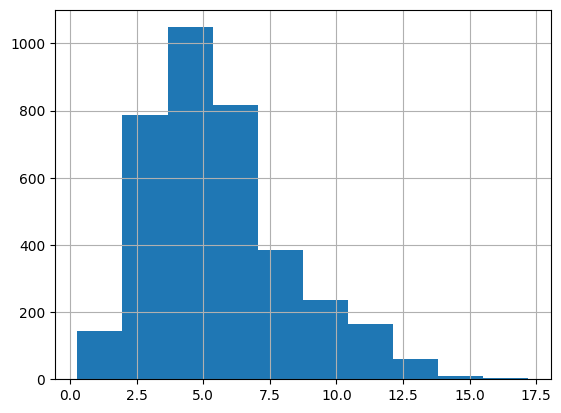

In [ ]:
# Pivot
ws=pd.DataFrame(ws_sard,copy=True)
ws["timestamp_col"]=ws.index.tz_localize("America/Bogota")
ws["fecha"] = ws["timestamp_col"].dt.date
ws["hora"]=ws["timestamp_col"].dt.hour
# renorm=7/ws["WS50M_Sardinata"].mean()
df = ws.pivot(index=["fecha"], columns="hora", values="WS50M_Sardinata").dropna()
df.columns = [f"WS_{str(col).zfill(2)}" for col in df.columns]
df.reset_index(inplace=True)
df["WS_05"].hist()
print(df.columns[1:])
df.head()

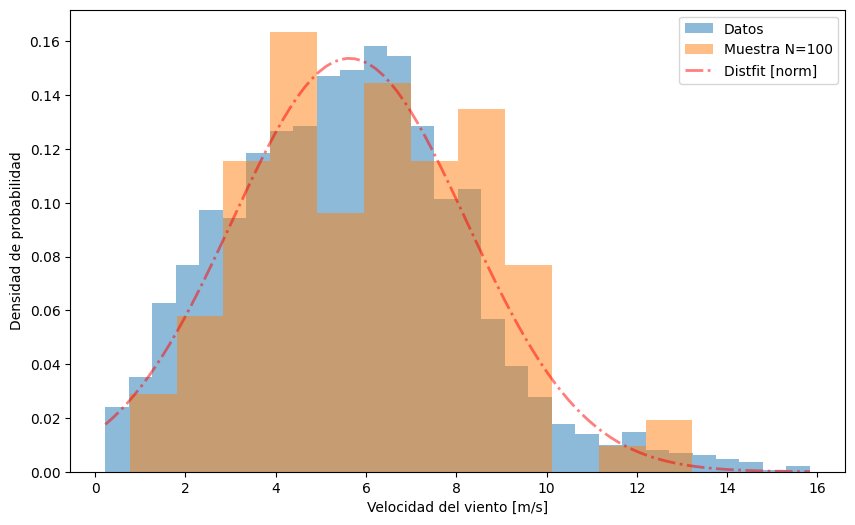

In [ ]:
# # Creating the wind pdf models
# windmodels=[]
# for col in df.columns[1:]:
#     data = df[col]
#     #### Usando Distfit
#     dist=distfit()
#     _=dist.fit_transform(data.values,verbose=40)    
#     model_min=float(data.min())
#     model_max=float(data.max())
#     params=[str(i) for i in dist.model['params']]
#     model_info={'series':col,
#                 'min':model_min,'max':model_max,
#                 'pdfname':dist.model['name'],
#                 'params':params}
#     windmodels.append(model_info)
#     # print(dist.model)
#     # _=dist.plot() # Simpler plot, closed tho

# winddict={'wind':windmodels}

# with open('WindPDF.yaml','w') as f:    
#     yaml.dump(winddict,f)
from distfit import distfit
import scipy.stats as stats 
import yaml
import numpy as np
import matplotlib.pyplot as plt
with open('WindPDF.yaml','r') as f:    
    windinfo=yaml.safe_load(f)


# Getting p(x) for plotting hour=11
Npoints=100
hh=11
WSpdf_hh=windinfo['wind'][hh]
x=np.linspace(WSpdf_hh['min'],WSpdf_hh['max'],Npoints)
pdf_obj=getattr(stats,WSpdf_hh['pdfname'])
params=[float(i) for i in WSpdf_hh['params']]
p_dfit=pdf_obj.pdf(x,*params)

# Sampling the PDF
rng=np.random.default_rng()
Nsamples=100
oversample=int(Nsamples/5)
max_=WSpdf_hh['max']
min_=WSpdf_hh['min']
sample=np.array(pdf_obj.rvs(*params,size=Nsamples+oversample,random_state=rng))
# oversample and delete out-of-bounds
sample=sample[(min_<=sample)&(sample<=max_)]
if len(sample)>=Nsamples:
    sample=sample[:Nsamples]
else:
    raise Exception("oversample too short")

# Graficar 1 hora
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df[f"WS_{hh}"], bins=30, density=True, alpha=0.5, label="Datos")
ax.hist(sample, density=True, bins=12,alpha=0.5, label=f"Muestra N={Nsamples}")
ax.plot(x,p_dfit,'r-.',lw=2,label=f"Distfit [{WSpdf_hh['pdfname']}]",alpha=0.5)
# ax.plot(x, p_stats, 'b-', lw=2, label=f"Stats: {mod_name}",alpha=0.5)
ax.set_xlabel("Velocidad del viento [m/s]")
ax.set_ylabel("Densidad de probabilidad")
plt.legend()
plt.show()


# # Graficar las 24 horas
# Npoints=100
# fig=plt.figure(figsize=(10,20))
# ax=fig.add_subplot(projection='3d')
# T=24
# for t in range(T):
#     ws_h=windinfo['wind'][t]
#     x=np.linspace(ws_h['min'],ws_h['max'],Npoints)
#     pdf_obj=getattr(stats,ws_h['pdfname'])
#     params=[float(i) for i in ws_h['params']]
#     p_dfit=pdf_obj.pdf(x,*params)
#     ax.plot(x,np.zeros(Npoints)+t,p_dfit/max(p_dfit),'r-.',lw=2)
    
#     hist,bins=np.histogram(df[f"WS_{str(t).zfill(2)}"].tolist(),bins=20)
#     ax.bar((bins[:-1] + bins[1:])/2, 0.9*hist/max(hist),zs=t,width=(bins[1]-bins[0])*0.8, zdir='y', alpha=0.8)
    
# ax.set_yticks(range(24))
# ax.set_yticklabels(range(24))
# # ax.set_ylim([5,18])
# ax.set_ylabel("\nHora",fontsize=12,linespacing=2)
# # ax.set_xlim([-100,1100])
# ax.set_xlabel("Velocidad del viento [m/s]",fontsize=12)
# ax.view_init(20,-20)
# ax.set_zlim([0,1.1])
# ax.set_zlabel("Densidad de probabilidad (Normlz.)",fontsize=12)
# ax.set_box_aspect(aspect=(2.5,4,1))
# fig.savefig('windPDFs.png',dpi=500)
# plt.show()
# # plt.ion()




## Sample Data for Solar Resources

In [ ]:
### IMPORTAR DATOS DE SOLCAST
import pandas as pd

path="SolarData/Solcast_PuertoCarreno.csv"
df=pd.read_csv(path, parse_dates=["PeriodStart"],sep=';')
df["timestamp_col"]=df['PeriodStart'].dt.tz_convert("America/Bogota")
df["fecha"] = df["timestamp_col"].dt.date
df["hora"]=df["timestamp_col"].dt.hour
# df["mediahora"] = df["timestamp_col"].dt.hour.astype(str).str.zfill(2)+"_"+df["timestamp_col"].dt.minute.astype(str)
df["n_en_hora"]=df.groupby(['fecha','hora']).cumcount()
df_pivot = df.pivot(index=["fecha", "n_en_hora"], columns="hora", values="GtiFixedTilt").dropna()
df_pivot.columns = [f"GTI_{str(col).zfill(2)}" for col in df_pivot.columns]
df_pivot.reset_index(inplace=True)
# df_pivot[df_pivot['GTI_19']<0]
df_pivot.head()
## CONVERTIR A KW

,fecha,n_en_hora,GTI_00,GTI_01,GTI_02,GTI_03,GTI_04,GTI_05,GTI_06,GTI_07,...,GTI_14,GTI_15,GTI_16,GTI_17,GTI_18,GTI_19,GTI_20,GTI_21,GTI_22,GTI_23
0,2014-12-31,0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,254.0,...,540.0,486.0,290.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2014-12-31,1,0.0,0.0,0.0,0.0,0.0,0.0,30.0,320.0,...,436.0,377.0,248.0,53.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2014-12-31,2,0.0,0.0,0.0,0.0,0.0,0.0,87.0,386.0,...,547.0,345.0,176.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2014-12-31,3,0.0,0.0,0.0,0.0,0.0,0.0,181.0,450.0,...,613.0,317.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2015-01-01,0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,250.0,...,855.0,658.0,412.0,146.0,0.0,0.0,0.0,0.0,0.0,0.0


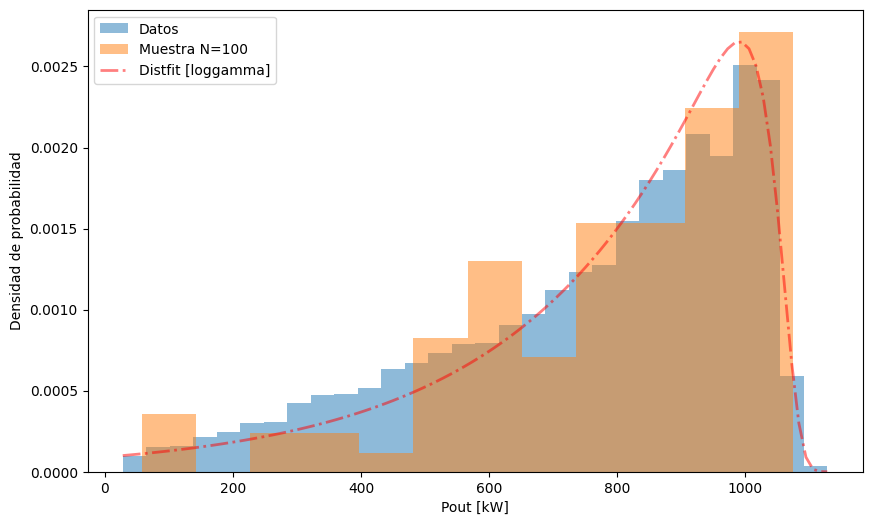

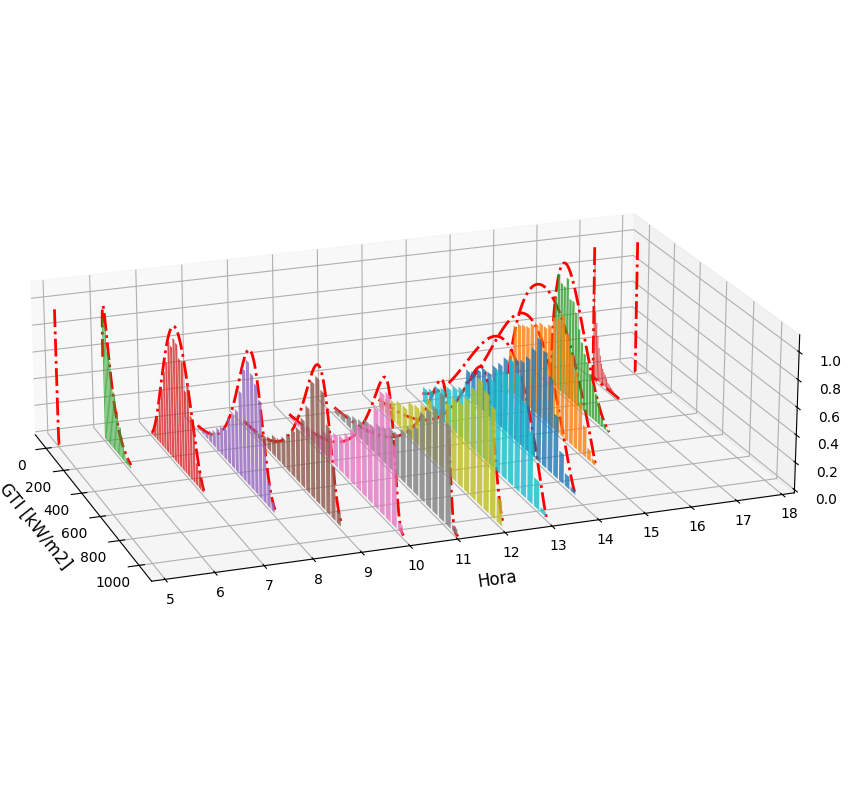

In [ ]:
from distfit import distfit
import scipy.stats as stats 
import yaml
import numpy as np
import matplotlib.pyplot as plt

# # Creating the solar pdf models
# solarmodels=[]
# for col in df_pivot.columns[2:]:
#     data = df_pivot[col]
#     #### Usando Distfit
#     dist=distfit()
#     _=dist.fit_transform(data.values,verbose=40)    
#     model_min=float(data.min())
#     model_max=float(data.max())
#     params=[str(i) for i in dist.model['params']]
#     model_info={'series':col,
#                 'min':model_min,'max':model_max,
#                 'pdfname':dist.model['name'],
#                 'params':params}
#     solarmodels.append(model_info)
#     # print(dist.model)
#     # _=dist.plot() # Simpler plot, closed tho

# solardict={'solar':solarmodels}

# with open('SolarPDF.yaml','w') as f:    
#     yaml.dump(solardict,f)

# Reading
with open('SolarPDF.yaml','r') as f:    
    solarinfo=yaml.safe_load(f)

# Getting p(x) for plotting hour=11
Npoints=100
hh=11
GTIpdf_hh=solarinfo['solar'][hh]
x=np.linspace(GTIpdf_hh['min'],GTIpdf_hh['max'],Npoints)
pdf_obj=getattr(stats,GTIpdf_hh['pdfname'])
params=[float(i) for i in GTIpdf_hh['params']]
p_dfit=pdf_obj.pdf(x,*params)

# Sampling the PDF
rng=np.random.default_rng()
Nsamples=100
oversample=int(Nsamples/5)
max_=GTIpdf_hh['max']
min_=GTIpdf_hh['min']
sample=np.array(pdf_obj.rvs(*params,size=Nsamples+oversample,random_state=rng))
# Cut sample to bounds
# sample=[min(max(GTIpdf_hh['min'],si),GTIpdf_hh['max']) for si in sample]
# No, this approach gives me too many in bounds, oversample and delete those
sample=sample[(min_<=sample)&(sample<=max_)]
# sample=sample[sample<=max_]
if len(sample)>=Nsamples:
    sample=sample[:Nsamples]
else:
    raise Exception("oversample too short")

# Graficar 1 hora
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_pivot[f"GTI_{hh}"], bins=30, density=True, alpha=0.5, label="Datos")
ax.hist(sample, density=True, bins=12,alpha=0.5, label=f"Muestra N={Nsamples}")
ax.plot(x,p_dfit,'r-.',lw=2,label=f"Distfit [{GTIpdf_hh['pdfname']}]",alpha=0.5)
# ax.plot(x, p_stats, 'b-', lw=2, label=f"Stats: {mod_name}",alpha=0.5)
ax.set_xlabel("Pout [kW]")
ax.set_ylabel("Densidad de probabilidad")
plt.legend()
plt.show()

# Graficar las 24 horas
fig=plt.figure(figsize=(10,20))
ax=fig.add_subplot(projection='3d')
T=24
for t in range(T)[4:-2]:
    GTIpdf_hh=solarinfo['solar'][t]
    x=np.linspace(GTIpdf_hh['min'],GTIpdf_hh['max'],Npoints)
    pdf_obj=getattr(stats,GTIpdf_hh['pdfname'])
    params=[float(i) for i in GTIpdf_hh['params']]
    p_dfit=pdf_obj.pdf(x,*params)
    ax.plot(x,np.zeros(Npoints)+t,p_dfit/max(p_dfit),'r-.',lw=2)
    
    hist,bins=np.histogram(df_pivot[f"GTI_{str(t).zfill(2)}"].tolist(),bins=20)
    ax.bar((bins[:-1] + bins[1:])/2, 0.9*hist/max(hist),zs=t,width=(bins[1]-bins[0])*0.8, zdir='y', alpha=0.8)
    
ax.set_yticks(range(23))
ax.set_yticklabels(range(23))
ax.set_ylim([5,18])
ax.set_ylabel("\nHora",fontsize=12,linespacing=2)
ax.set_xlim([-100,1100])
ax.set_xlabel("GTI [kW/m2]",fontsize=12)
ax.view_init(20,-20)
ax.set_zlim([0,1.1])
ax.set_zlabel("Densidad de probabilidad (Normlz.)",fontsize=12)
ax.set_box_aspect(aspect=(2.5,4,1))
# fig.savefig('solarPDFs.png',dpi=500)
plt.show()
# plt.ion()

# #### Usando stats.{pdf}.fit, aunque me toca meterle todos los nombres, más aburrido
# pdfs=['weibull_min','gamma','lognorm','beta','norm']
# kst,stats_model,mod_name=pdf=1,None,''
# for pdf in pdfs:
#     model_i=getattr(stats,pdf).fit(data)
#     kstest_i=stats.kstest(data,pdf,args=model_i)
#     if kstest_i.statistic<=kst:
#         kst=kstest_i.statistic
#         stats_model=model_i
#         mod_name=pdf
# # stats_model = stats.weibull_min.fit(data)
# p_stats = getattr(stats,mod_name).pdf(x, *stats_model)

## Diseño de Microrredes de Prueba
### Realistic Microgrid Cases

Se usarán estos rangos de precios de energía

- eolica 90-110
- solar 90-100
- biomasa 180-250
- gas nac 240-250
- hidro 270-340
- pch 320-350
- carbon 800-900
- gas importado 700-900
- acpm/diesel 900-1000

Para el despacho determinísitico haz un pequeño análisis de ahorro en la energía diaria con el BESS vs costo del BESS variando el tamaño como un % de la generación diaria promedio/esperada del SPV/WP

También calcula y presenta el nivel de penetración de energía renovable variable (energia promedio entregada diaria o anual por fuentes variable/entregada total). Busca el nivel de penetración total en Colombia, en la tesis de brasil hay de otros países.

TOP site for BESS cost estim https://www.pnnl.gov/projects/esgc-cost-performance/lithium-ion-battery

According to the indians, ~0.6m3 of biomass can be produced from 1kg of cow shit, producing 1.5kWh, one cow produces 5.5kg daily


Zipaemg 2 data:
Coal 36MWp
2MW/h para MS
upramp 9MW/h
downramp 21MW/h

Termosierra CC data:
Conf1 Gas de 139MWp
upramp 74MW/h
downramp 74MW/h

Conf6 Diesel de 110MWp
upramp 21MW/h
downramp 21MW/h

Bajo Achincaya 1 data:
Hidro 12MWp
ramps 12MW/min lol

La Loma 1 data:
Solar 150MWp
ramps 20MW/min lol

Basically, in p.u./h
> Coal ~0.3, 0.6
> Diesel ~0.2, 0.2
> Gas ~0.5, 0.5
> Diesel

Wind 1-5MW has ~30% capacity factor usually

In [ ]:
## Defining Example Microgrids (whiteboard)

# Puerto Carreño-ish (6MW gas? 5MW PV?)
PC_diesel=6445
PC_dem_curve=np.array([0.857, 0.847, 0.796, 0.753, 0.745, 0.714, 0.673, 0.714, 0.765,0.786, 0.837, 0.878, 0.878, 0.959, 1., 0.98 , 0.959, 0.918,0.939, 0.959, 0.98 , 0.994, 0.959, 0.898])
PC_solar=5000
PC_day_dem=100800
PC_peak_dem=PC_day_dem/np.sum(PC_dem_curve)
PC_peak_dem
# Puerto Carreño-Causarito-ish
PCC_solar=372.6
PCC_batcap=1182.72
PCC_diesel=132
PCC_familias=239
PCC_cost_COP=6190e6
# Bahia Solano inspired (2MW PCH, 1.8MW diesel)
# smol SPV based CE (500ppl ~100kWp, Solar covered w 6-8h BMS)
# SPV Biomasa Agribiz (?)
# SPV Diesel Big industry (800kWp continuous, 1MW Diesel 2MW SPV)
# WP SPV BESS farm (500kWp, 100kWx6 WT 100kW SPV 4h BMS)

4848.951318068116

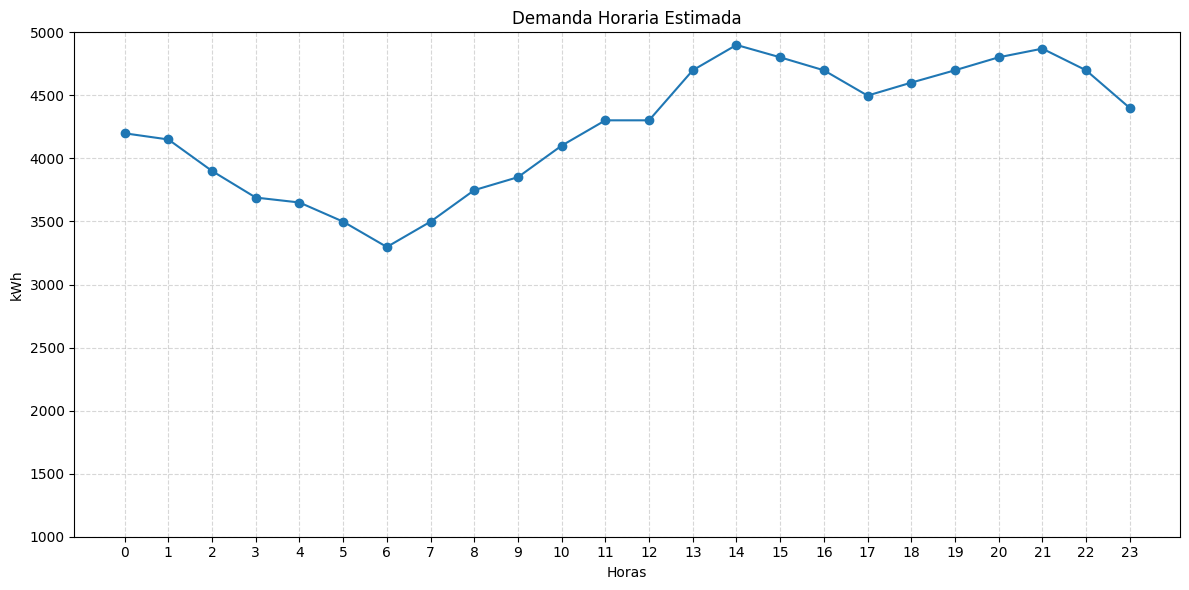

In [ ]:
# PUERTO CARREÑO MARZO 2025

#Demanda
Pmaxmax_kw=5734
Pmax_kw=4870
DemMonth_kwh=3125929
DemDay_kwh=100836

#Generación
SPVmax_kw=372
BESScap_kwh=1182
BESSpow_kw=600 #probably, idk
Diesel1max_kw=132 
Diesel1max_kw=4480 #6 x 560 Leroy Somer Diesel - Refoenergy, 1000cop/kwh BTW
Biomass2max_kw=4500 #1 x 4.5 Triveni - Refoenergy
#Refoenergy generó 18.5GWh Ene-Oct 2021, 2.3 (12,4%) fueron Biomasa, costo total 26MUSD, para 18k personas. "32.613 TBiomass que permitirán producir 22.647.611 kWh para 2022"


import matplotlib.pyplot as plt

horas = list(range(24))
kWh = np.array([0.857, 0.847, 0.796, 0.753, 0.745, 0.714, 0.673, 0.714, 0.765,0.786, 0.837, 0.878, 0.878, 0.959, 1.   , 0.98 , 0.959, 0.918,0.939, 0.959, 0.98 , 0.994, 0.959, 0.898])*4900

plt.figure(figsize=(12, 6))
plt.plot(horas, kWh, marker='o')
plt.xlabel('Horas')
plt.ylabel('kWh')
plt.title('Demanda Horaria Estimada')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(1000,5000)
plt.xticks(horas)
plt.tight_layout()
plt.show()
